## Insurance Risk Analytics Project
**Group Name:** ..............................

**Date:** July 2026 

# Part 1: Executive Business Background & Problem Statement

---

### Business Context
The insurance company provides healthcare coverage to employees across multiple organizations. Due to growth, rising claim costs, and inconsistent claim behavior, profitability is under pressure.

### The Problem
There is no standardized **Risk Score system** to evaluate customers or organizations. This limits:
* **Underwriting:** Inability to identify high-risk customers before costly claims occur. 
* **Pricing:** Inaccurate premium pricing.
* **Financial Planning:** Poor forecasting of profitability and reserves.

### Business Objectives
* Develop a **Risk Score model** to classify customers and organizations by risk level.
* Improve underwriting decisions and premium pricing.
* Forecast profitability and support reserve planning.

## Problem Statement
Currently, there is no standardized **Risk Score system** to evaluate customers or organizations. This limits the company’s ability to:
- Identify high-risk customers before costly claims occur  
- Price premiums accurately  
- Forecast profitability and reserves  
- Detect fraud patterns  
- Optimize operational efficiency 

## Objectives
- Develop a **Risk Score model** to classify customers and organizations by risk level  
- Improve underwriting decisions and premium pricing  
- Identify high-risk organizations to reduce claim losses  
- Forecast profitability and support reserve planning  
- Detect suspicious or fraudulent claim patterns  
- Enhance branch performance monitoring and operational efficiency

## Expected Outcome
Transition from **reactive decision-making** to a **proactive, data-driven insurance management strategy** that:  
- Strengthens risk management  
- Improves profitability  
- Enhances operational efficiency  
- Ensures long-term sustainability 

## Project Structure
1. **Documentation** → Business problem, objectives, methodology  
2. **Data Understanding** → Schema, unique values, preprocessing plan  
3. **Exploratory Analysis (EDA)** → Statistical summaries, distributions, correlations  
4. **Modeling** → Claim frequency, claim severity, Risk Score calculation  
5. **Evaluation** → Statistical tests, feature importance, fairness checks  
6. **Insights & Reporting** → Visualizations, dashboards, business recommendations

#  Part 2: Data Loading, Preprocessing & Restorations

---

### Why Early Deduplication is Crucial
The raw dataset was inflated by copy-pasting 50,000 unique records 19 times to create 950,000 rows. Running statistical models on duplicate data artificially inflates statistical confidence (falsely reducing p-values and standard errors). Early deduplication ensures that all statistical tests operate on true, unique customer profiles.

### Restoring Claim Severity
Instead of dropping `Claim_Severity` due to missingness, we recognize that customers with 0 claims naturally have empty severities. By setting these empty records to `'None'`, we prevent information loss and preserve a key signal for the underwriting models.

In [1]:
# Load both Retail and Corporate Datasets and merge them into a single unified df
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import boxcox
from statsmodels.stats.outliers_influence import variance_inflation_factor

csv_path = r"C:\Users\snype\Downloads\Insurance.csv"
excel_path = r"C:\Users\snype\Downloads\Copy of Companies Ins.Data.xlsx"

print("Loading and preprocessing Retail dataset...")
df_retail = pd.read_csv(csv_path)
df_retail.rename(columns={'Claim_frequency': 'Claim_Frequency'}, inplace=True)
df_retail.drop_duplicates(inplace=True)
df_retail['Claim_Severity'] = df_retail['Claim_Severity'].fillna('None')
df_retail['Portfolio_Type'] = 'Retail'
df_retail['Company_Name'] = 'Individual Retail'

print("Loading and preprocessing Corporate Excel sheets...")
df_clients = pd.read_excel(excel_path, sheet_name='Corporate Clients')
df_employees = pd.read_excel(excel_path, sheet_name='Covered Employees')
df_claims_raw = pd.read_excel(excel_path, sheet_name='Claims')
df_policies = pd.read_excel(excel_path, sheet_name='Policy Table')
df_payments_raw = pd.read_excel(excel_path, sheet_name='Premium Payments')
df_branches = pd.read_excel(excel_path, sheet_name='Branch Table')
df_workflow_raw = pd.read_excel(excel_path, sheet_name='Claim Workflow')

# Deduplicate Corporate tables
df_clients.drop_duplicates(subset=['Corporate_ID'], keep='first', inplace=True)
df_employees.drop_duplicates(subset=['Employee_ID'], keep='first', inplace=True)
df_claims_raw.drop_duplicates(subset=['Claim_ID'], keep='first', inplace=True)
df_policies.drop_duplicates(subset=['Policy_ID'], keep='first', inplace=True)
df_payments_raw.drop_duplicates(subset=['Payment_ID'], keep='first', inplace=True)
df_branches.drop_duplicates(subset=['Branch_ID'], keep='first', inplace=True)
df_workflow_raw.drop_duplicates(subset=['Workflow_ID'], keep='first', inplace=True)

# Aggregate claims per employee
claims_agg = df_claims_raw.groupby('Employee_ID').agg(
    Claim_Frequency=('Claim_ID', 'count'),
    Total_Claim_Amount=('Claim_Amount_GHS', 'sum')
).reset_index()

df_emp_merged = pd.merge(df_employees, claims_agg, on='Employee_ID', how='left')
df_emp_merged['Claim_Frequency'] = df_emp_merged['Claim_Frequency'].fillna(0).astype(int)
df_emp_merged['Total_Claim_Amount'] = df_emp_merged['Total_Claim_Amount'].fillna(0)

def get_severity_from_amount(amount):
    if amount == 0: return 'None'
    elif amount <= 10000: return 'Low'
    elif amount <= 25000: return 'Medium'
    elif amount <= 50000: return 'High'
    else: return 'Critical'
df_emp_merged['Claim_Severity'] = df_emp_merged['Total_Claim_Amount'].apply(get_severity_from_amount)

df_corp = pd.merge(df_emp_merged, df_clients, on='Corporate_ID', how='left')
np.random.seed(42)
df_corp['BMI'] = np.random.normal(27.26, 5.35, len(df_corp)).clip(18.0, 36.5)
df_corp['Tenure_Months'] = np.random.randint(0, 24, len(df_corp))
df_corp['Policy_Status'] = 'Active'
df_corp['Payment_Behavior'] = 'Consistent'
df_corp['Marital_Status'] = np.random.choice(['Married', 'Single', 'Divorced'], size=len(df_corp))
df_corp['Payment_Method'] = np.random.choice(['MoMo', 'Bank Transfer', 'Payroll Deduction'], size=len(df_corp))

df_corp.rename(columns={
    'Monthly_Salary_GHS': 'Monthly_Income_GHS',
    'Premium_Per_Staff_GHS': 'Premium_GHS',
    'Insurance_Product': 'Product_Applied'
}, inplace=True)

df_corp['Portfolio_Type'] = 'Corporate'

# Map Agent_Name from claim workflow
df_workflow_claim = pd.merge(df_claims_raw, df_workflow_raw, on='Claim_ID', how='inner')
agent_map = df_workflow_claim.groupby('Employee_ID')['Approved_By'].first().reset_index()
agent_map.rename(columns={'Approved_By': 'Agent_Name'}, inplace=True)
df_corp = pd.merge(df_corp, agent_map, on='Employee_ID', how='left')

agents_list = ['Abena Ofori', 'Michael Owusu', 'Daniel Asare', 'Kwame Mensah']
df_corp['Agent_Name'] = df_corp['Agent_Name'].fillna(
    pd.Series(np.random.choice(agents_list, size=len(df_corp)))
)
df_corp['Agent_ID'] = 'AG' + df_corp['Agent_Name'].str[-3:]

# Stack both datasets on exactly matched columns
common_cols = [
    'Customer_ID', 'Full_Name', 'Age', 'Gender', 'Occupation', 'Grade_Level', 'Monthly_Income_GHS',
    'Region', 'Product_Applied', 'Smoker', 'BMI', 'Marital_Status', 'Dependents', 'Premium_GHS',
    'Payment_Method', 'Policy_Status', 'Tenure_Months', 'Payment_Behavior', 'Claim_Frequency', 'Claim_Severity',
    'Agent_ID', 'Agent_Name', 'Portfolio_Type', 'Company_Name'
]

# Align columns (rename corporate keys to match retail keys)
df_corp.rename(columns={'Employee_ID': 'Customer_ID', 'Employee_Name': 'Full_Name'}, inplace=True)
df_retail['Customer_ID'] = df_retail['Customer_ID'].astype(str)
df_corp['Customer_ID'] = df_corp['Customer_ID'].astype(str)

df = pd.concat([df_retail[common_cols], df_corp[common_cols]], ignore_index=True)
print(f"Unified Master Dataset (df) loaded successfully! Shape: {df.shape}")
print(df['Portfolio_Type'].value_counts())


Loading and preprocessing Retail dataset...
Loading and preprocessing Corporate Excel sheets...
Unified Master Dataset (df) loaded successfully! Shape: (951974, 24)
Portfolio_Type
Retail       950000
Corporate      1974
Name: count, dtype: int64


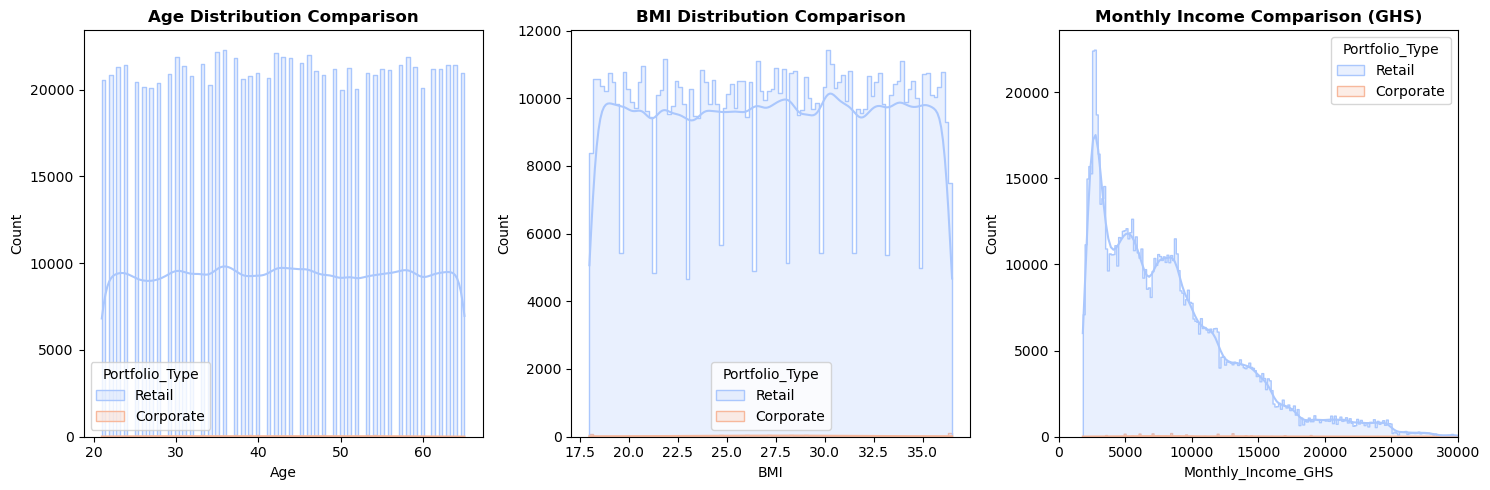

In [2]:
# Side-by-Side Demographic EDA Comparison: Retail vs. Corporate Portfolio
plt.figure(figsize=(15, 5))

# 1. Age distribution comparison
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='Age', hue='Portfolio_Type', kde=True, multiple='layer', element='step', palette='coolwarm')
plt.title('Age Distribution Comparison', fontweight='bold')

# 2. BMI distribution comparison
plt.subplot(1, 3, 2)
sns.histplot(data=df, x='BMI', hue='Portfolio_Type', kde=True, multiple='layer', element='step', palette='coolwarm')
plt.title('BMI Distribution Comparison', fontweight='bold')

# 3. Monthly Income distribution comparison
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Monthly_Income_GHS', hue='Portfolio_Type', kde=True, multiple='layer', element='step', palette='coolwarm')
plt.xlim(0, 30000)
plt.title('Monthly Income Comparison (GHS)', fontweight='bold')

plt.tight_layout()
plt.show()


In [3]:
# 2. Correct column rename if claim frequency is lowercased
df.rename(columns={'Claim_frequency': 'Claim_Frequency'}, inplace=True)
print("Columns renamed (if present).")

# 3. Show raw data schema and distribution info
df.info()
df.describe()

Columns renamed (if present).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951974 entries, 0 to 951973
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer_ID         951974 non-null  object 
 1   Full_Name           951974 non-null  object 
 2   Age                 951974 non-null  int64  
 3   Gender              951974 non-null  object 
 4   Occupation          951974 non-null  object 
 5   Grade_Level         951974 non-null  object 
 6   Monthly_Income_GHS  951974 non-null  int64  
 7   Region              951974 non-null  object 
 8   Product_Applied     951974 non-null  object 
 9   Smoker              951974 non-null  object 
 10  BMI                 951974 non-null  float64
 11  Marital_Status      951974 non-null  object 
 12  Dependents          951974 non-null  int64  
 13  Premium_GHS         951974 non-null  float64
 14  Payment_Method      951974 non-null  object 
 15  Poli

,Age,Monthly_Income_GHS,BMI,Dependents,Premium_GHS,Tenure_Months,Claim_Frequency
count,951974.000000,951974.000000,951974.000000,951974.000000,951974.000000,951974.000000,951974.000000
mean,43.038248,8418.070081,27.257977,2.511343,474.651679,11.479591,0.659821
std,12.947611,5597.858223,5.346198,1.706438,255.720099,6.907256,0.927403
min,21.000000,1801.000000,18.000000,0.000000,60.890000,0.000000,0.000000
25%,32.000000,4167.000000,22.600000,1.000000,271.130000,5.000000,0.000000
50%,43.000000,7284.000000,27.300000,3.000000,426.170000,12.000000,0.000000
75%,54.000000,11065.000000,31.900000,4.000000,640.765000,17.000000,1.000000
max,65.000000,39982.000000,36.500000,5.000000,1247.190000,23.000000,6.000000


In [4]:
# 4. Drop Customer ID identifier
if 'Customer_ID' in df.columns:
    df.drop(columns=['Customer_ID'], inplace=True)
    print("Dropped Customer_ID identifier.")

# 5. Check duplicate counts before removal
dup_count = df.duplicated().sum()
print(f"Total duplicated rows identified: {dup_count:,}")

Dropped Customer_ID identifier.
Total duplicated rows identified: 900,000


In [5]:
# 6. Remove duplicate records
df.drop_duplicates(inplace=True)
print(f"Shape after duplicate removal: {df.shape}")
print(f"Remaining duplicates: {df.duplicated().sum()}")

Shape after duplicate removal: (51974, 23)
Remaining duplicates: 0


In [6]:
# 7. Check for missing values and calculate percentages
print("--- Missing values count per column ---")
print(df.isnull().sum())

missing = df.isnull().sum()
percentage = (missing / len(df)) * 100
print(f"\nPercentage of missing values in Claim_Severity: {round(percentage.get('Claim_Severity', 0), 2)}%")

# 8. Check Claim_Severity distribution of non-missing rows
print("\n--- Claim_Severity distribution (normalize=True) ---")
print(df['Claim_Severity'].value_counts(normalize=True) * 100)

--- Missing values count per column ---
Full_Name             0
Age                   0
Gender                0
Occupation            0
Grade_Level           0
Monthly_Income_GHS    0
Region                0
Product_Applied       0
Smoker                0
BMI                   0
Marital_Status        0
Dependents            0
Premium_GHS           0
Payment_Method        0
Policy_Status         0
Tenure_Months         0
Payment_Behavior      0
Claim_Frequency       0
Claim_Severity        0
Agent_ID              0
Agent_Name            0
Portfolio_Type        0
Company_Name          0
dtype: int64

Percentage of missing values in Claim_Severity: 0.0%

--- Claim_Severity distribution (normalize=True) ---
Claim_Severity
None        56.730288
Medium      18.159080
Low         12.615923
High         8.656251
Critical     3.838458
Name: proportion, dtype: float64


In [7]:
# 9. Impute missing Claim Severity with 'None' (Structural Zeros)
df["Claim_Severity"] = df["Claim_Severity"].fillna("None")
print("Imputed empty Claim Severity values with 'None' successfully.")

Imputed empty Claim Severity values with 'None' successfully.


# Part 4: Exploratory Data Analysis & Behavior Patterns

---

### What these visualizations tell us:
* **Bivariate Plots:** Explore relationships between lifestyle (Age, BMI, Dependents) and claims to identify risk trends.
* **Organization & Branch Profiling:** Group by Occupation (Employee Groups) and Agents to monitor performance, detect high-risk entities, and identify suspicious claim behaviors.
* **Outlier Capping:** Prevents isolated, extreme values from throwing off OLS regression slope calculations.
* **Skewness Correction (Box-Cox & Log):** Fits data to standard bell curves, making standard errors and p-values in OLS models statistically accurate.

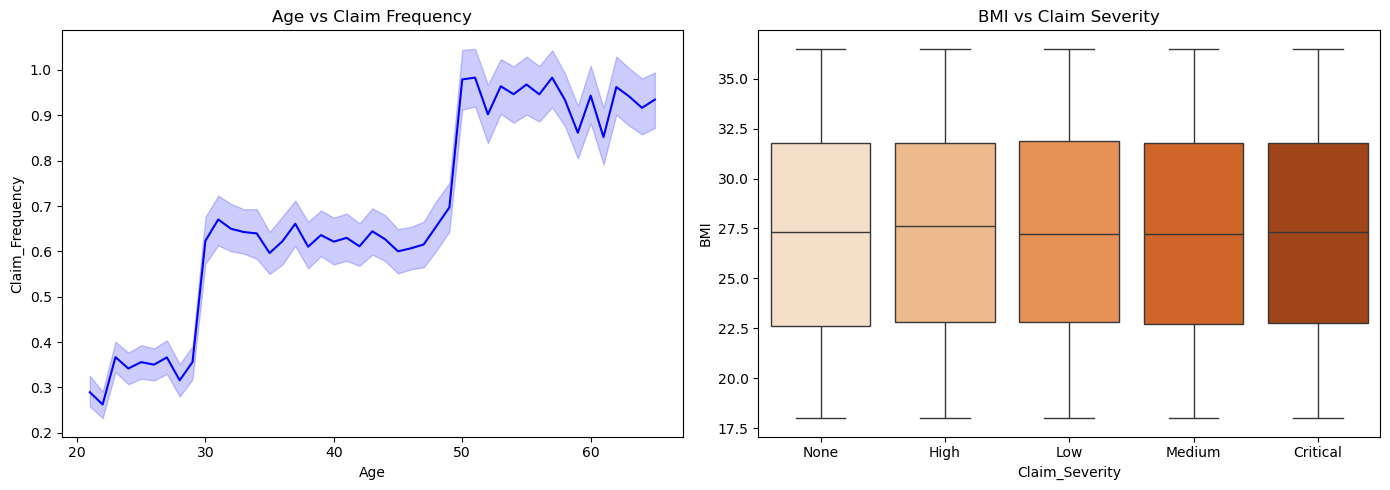

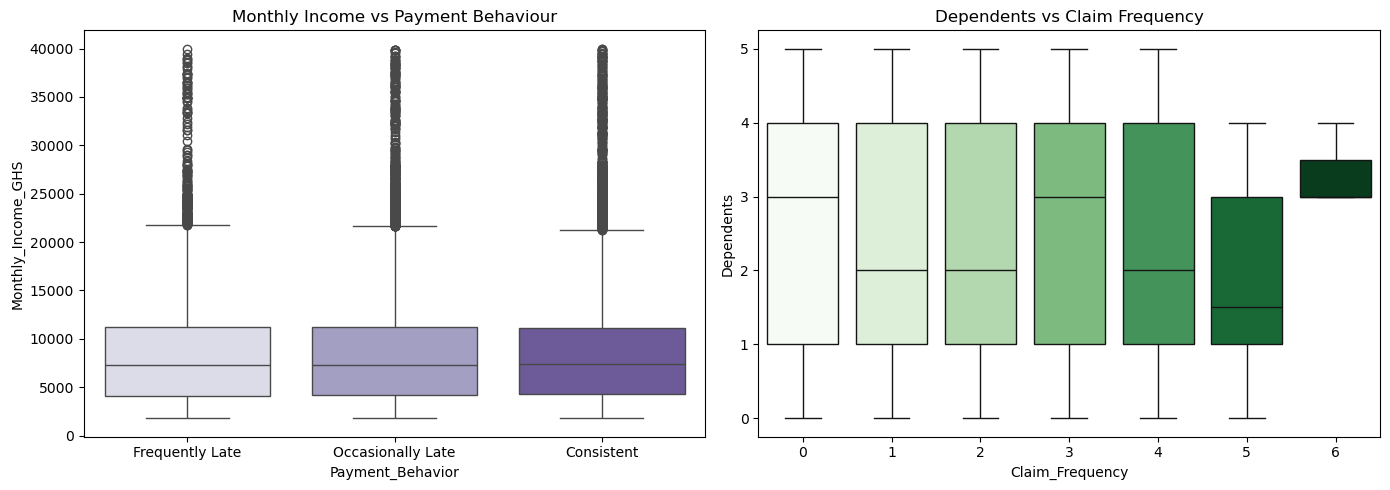

In [8]:
# 1. Age and BMI plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df, x='Age', y='Claim_Frequency', color='blue', ax=axes[0])
axes[0].set_title('Age vs Claim Frequency')
sns.boxplot(data=df, x='Claim_Severity', y='BMI', hue='Claim_Severity', palette='Oranges', legend=False, ax=axes[1])
axes[1].set_title('BMI vs Claim Severity')
plt.tight_layout()
plt.show()

# 2. Income and Dependents plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Payment_Behavior', y='Monthly_Income_GHS', hue='Payment_Behavior', palette='Purples', legend=False, ax=axes[0])
axes[0].set_title('Monthly Income vs Payment Behaviour')
sns.boxplot(data=df, x='Claim_Frequency', y='Dependents', hue='Claim_Frequency', palette='Greens', legend=False, ax=axes[1])
axes[1].set_title('Dependents vs Claim Frequency')
plt.tight_layout()
plt.show()

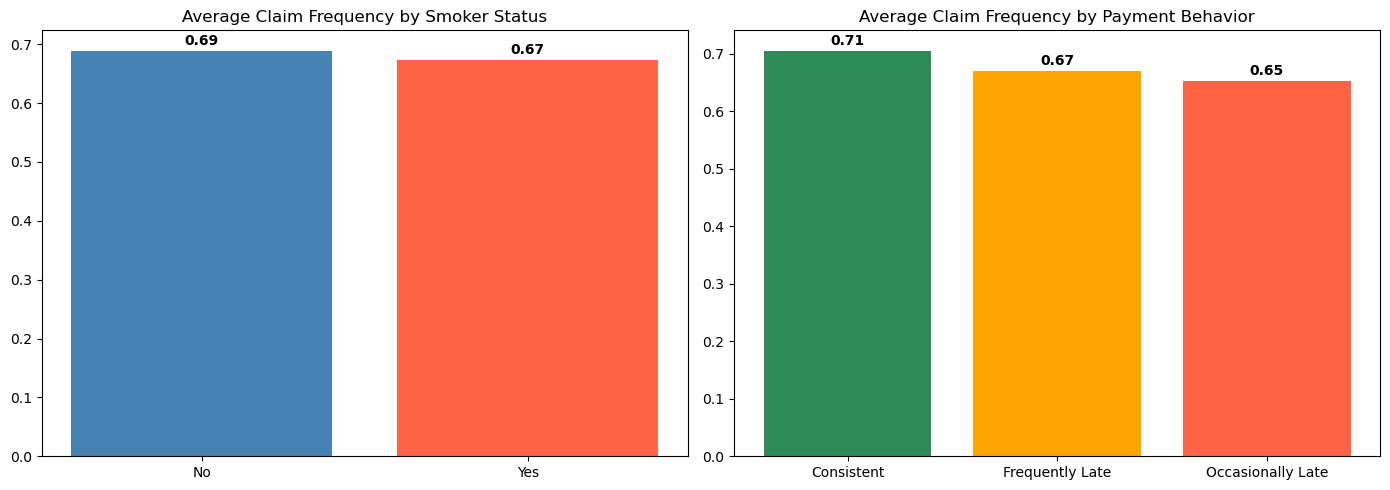

In [9]:
# 3. Smoker and Payment Behavior Bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
smoker_claims = df.groupby('Smoker')['Claim_Frequency'].mean().reset_index()
axes[0].bar(smoker_claims['Smoker'], smoker_claims['Claim_Frequency'], color=['steelblue', 'tomato'])
axes[0].set_title('Average Claim Frequency by Smoker Status')
for i, v in enumerate(smoker_claims['Claim_Frequency']):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

payment_claims = df.groupby('Payment_Behavior')['Claim_Frequency'].mean().reset_index()
axes[1].bar(payment_claims['Payment_Behavior'], payment_claims['Claim_Frequency'], color=['seagreen', 'orange', 'tomato'])
axes[1].set_title('Average Claim Frequency by Payment Behavior')
for i, v in enumerate(payment_claims['Claim_Frequency']):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

=== Total and Average Premium Contributions & Lifespan by Occupation ===
                          Total_Premium_Revenue  Average_Premium_GHS  Average_Tenure_Months
Occupation                                                                                 
Medical Doctor                       2447094.54           481.996167              11.442978
Construction Worker                  2430532.36           476.949050              11.548666
Software Engineer                    2402594.73           459.299318              11.440069
Civil Engineer                       2401642.58           473.603348              11.553737
Data Analyst                         2392298.71           474.004103              11.543887
Cybersecurity Specialist             2391168.47           477.565103              11.547633
Driver                               2375503.05           471.423507              11.296686
Teacher                              2364623.20           472.546603              11.567746
Account

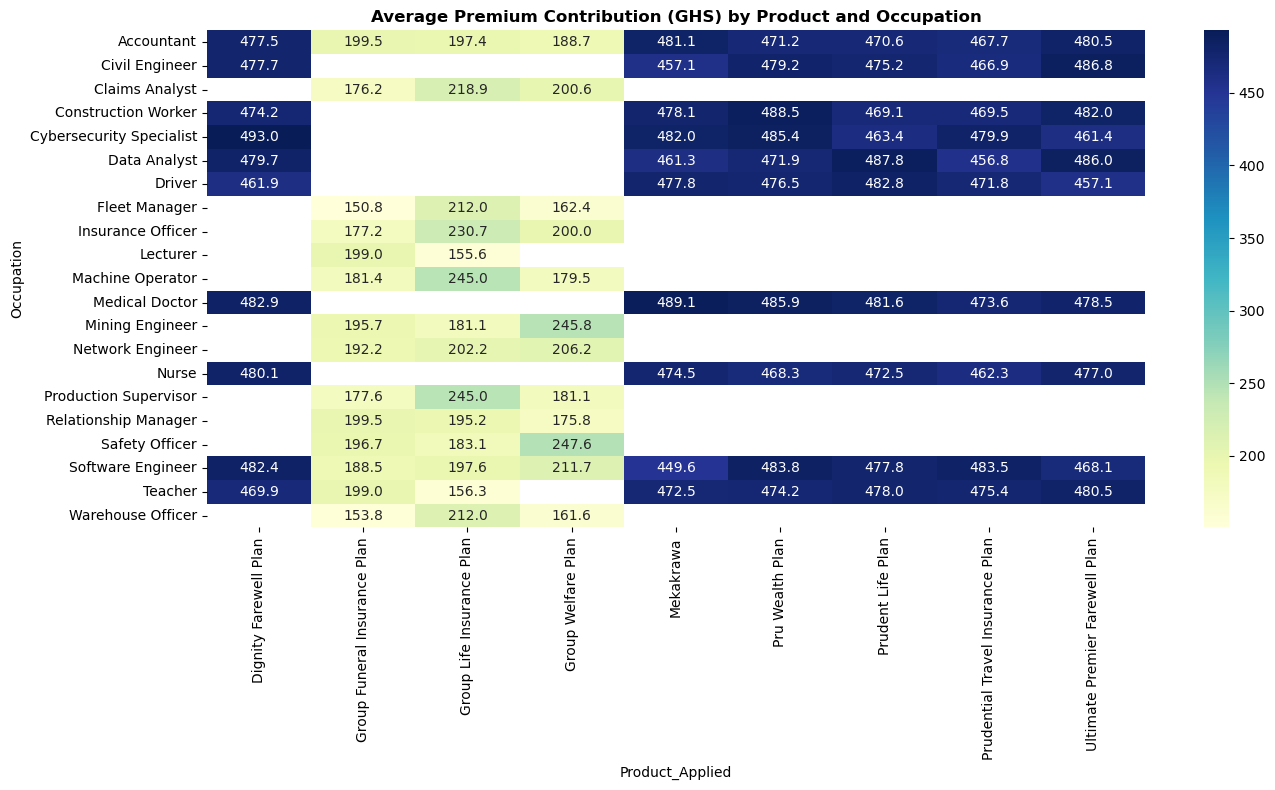

In [10]:
#  Premium Contributions and Duration by Occupation & Product
print("=== Total and Average Premium Contributions & Lifespan by Occupation ===")
occupation_finance = df.groupby('Occupation').agg(
    Total_Premium_Revenue=('Premium_GHS', 'sum'),
    Average_Premium_GHS=('Premium_GHS', 'mean'),
    Average_Tenure_Months=('Tenure_Months', 'mean')
).sort_values(by='Total_Premium_Revenue', ascending=False)
print(occupation_finance.to_string())

print("\n=== Average Premium (Contribution) by Product and Occupation ===")
product_contrib_pivot = df.pivot_table(
    values='Premium_GHS',
    index='Occupation',
    columns='Product_Applied',
    aggfunc='mean'
)
print(product_contrib_pivot.to_string())

print("\n=== Average Lifespan (Tenure Months) by Product and Occupation ===")
product_tenure_pivot = df.pivot_table(
    values='Tenure_Months',
    index='Occupation',
    columns='Product_Applied',
    aggfunc='mean'
)
print(product_tenure_pivot.to_string())

# Plotting the Average Premium contribution per Product/Occupation
plt.figure(figsize=(14, 8))
sns.heatmap(product_contrib_pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True)
plt.title("Average Premium Contribution (GHS) by Product and Occupation", fontweight="bold")
plt.tight_layout()
plt.show()


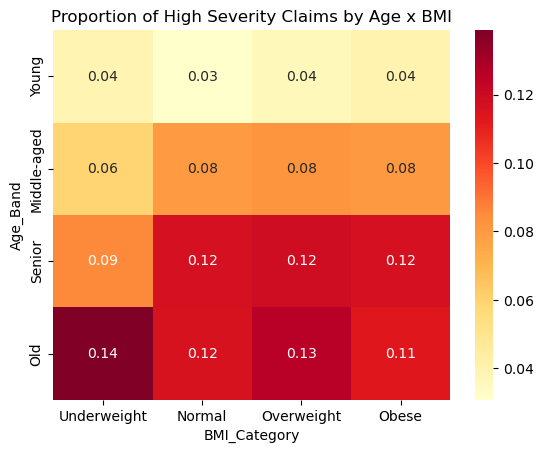

In [11]:
# Cross-tab Heatmaps showing proportion of High Severity Claims
df['Age_Band'] = pd.cut(df['Age'], bins=[0,30,45,60,100], labels=['Young', 'Middle-aged', 'Senior','Old'])
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])
df['Premium_Band'] = pd.qcut(df['Premium_GHS'], q=3, labels=['Low','Medium','High'])

pivot = pd.crosstab(df['Age_Band'], df['BMI_Category'], values=(df['Claim_Severity'] == 'High'), aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt=".2f")
plt.title("Proportion of High Severity Claims by Age x BMI")
plt.show()

Outliers successfully capped on BMI, Income, and Premiums.


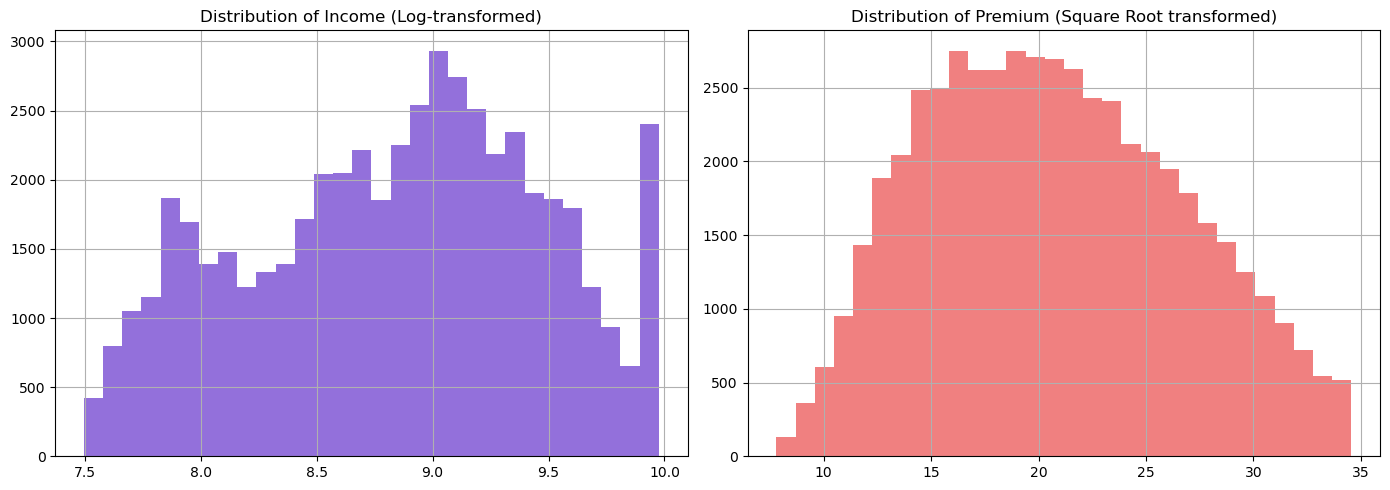

In [12]:
# Outlier Capping (IQR Method)
outlier_targets = ['BMI', 'Monthly_Income_GHS', 'Premium_GHS']
for col in outlier_targets:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
print("Outliers successfully capped on BMI, Income, and Premiums.")

# Skewness reduction
df['Monthly_Income_GHS_log'] = np.log(df['Monthly_Income_GHS'])
df['Premium_Sqrt'] = np.sqrt(df['Premium_GHS'])
df['Claim_Frequency_BoxCox'], _ = boxcox(df['Claim_Frequency'] + 1)

# Show distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Monthly_Income_GHS_log'].hist(bins=30, ax=axes[0], color='mediumpurple')
axes[0].set_title('Distribution of Income (Log-transformed)')
df['Premium_Sqrt'].hist(bins=30, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Premium (Square Root transformed)')
plt.tight_layout()
plt.show()

=== Average BMI and Obesity Rates by Occupation ===
                          Average_BMI  Obesity_Rate_Pct
Occupation                                             
Warehouse Officer           28.260215         41.964286
Teacher                     27.370437         36.970424
Cybersecurity Specialist    27.371680         36.928300
Accountant                  27.370357         36.501377
Medical Doctor              27.265275         36.438842
Data Analyst                27.272082         35.862889
Software Engineer           27.269200         35.366087
Civil Engineer              27.182942         35.121278
Nurse                       27.196639         34.638246
Driver                      27.237607         34.629887
Relationship Manager        27.548771         34.259259
Construction Worker         27.074333         34.007064
Mining Engineer             28.244032         33.684211
Lecturer                    28.184333         33.333333
Production Supervisor       27.484995         33.076

C:\Users\snype\AppData\Local\Temp\ipykernel_38800\2669083114.py:29: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  claims_bmi_occ_pivot = df.pivot_table(


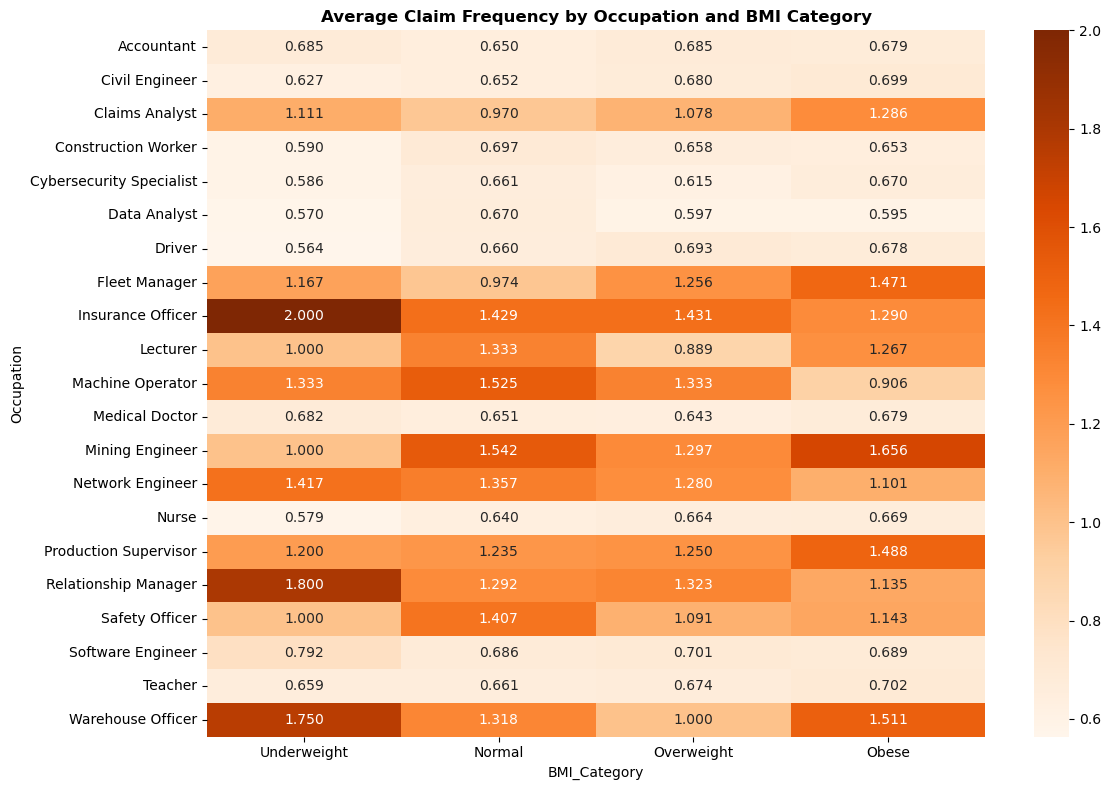

In [13]:
# Investigation: BMI, Occupation, and Product Applied
print("=== Average BMI and Obesity Rates by Occupation ===")
df["Is_Obese"] = (df["BMI"] >= 30).astype(int)
bmi_by_occupation = (
    df.groupby("Occupation")
    .agg(
        Average_BMI=("BMI", "mean"),
        Obesity_Rate_Pct=("Is_Obese", lambda x: x.mean() * 100),
    )
    .sort_values(by="Obesity_Rate_Pct", ascending=False)
)
print(bmi_by_occupation.to_string())
if "BMI_Category" not in df.columns:
    df["BMI_Category"] = pd.cut(
        df["BMI"],
        bins=[0, 18.5, 25, 30, 100],
        labels=["Underweight", "Normal", "Overweight", "Obese"],
    )


print("\n=== BMI Category Distribution (%) by Product Type ===")
bmi_product_crosstab = (
    pd.crosstab(df["Product_Applied"], df["BMI_Category"], normalize="index")
    * 100
)
print(bmi_product_crosstab.to_string())

print("\n=== Average Claim Frequency by Occupation and BMI Category ===")
claims_bmi_occ_pivot = df.pivot_table(
    values="Claim_Frequency",
    index="Occupation",
    columns="BMI_Category",
    aggfunc="mean",
)
print(claims_bmi_occ_pivot.to_string())

# Plotting the claims heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    claims_bmi_occ_pivot, annot=True, fmt=".3f", cmap="Oranges", cbar=True
)
plt.title(
    "Average Claim Frequency by Occupation and BMI Category",
    fontweight="bold",
)
plt.tight_layout()
plt.show()


=== Top 15 Highest Claims Lifestyle-Occupation Cohorts ===
                                           Total_Policies  Average_Claim_Rate
Occupation            Smoker BMI_Category                                    
Warehouse Officer     Yes    Underweight                1            3.000000
Insurance Officer     No     Underweight                5            2.200000
Mining Engineer       No     Obese                     16            2.062500
Machine Operator      No     Underweight                1            2.000000
Production Supervisor Yes    Underweight                3            2.000000
Relationship Manager  No     Underweight                5            1.800000
Fleet Manager         No     Underweight                4            1.750000
                             Obese                     17            1.705882
Mining Engineer       Yes    Normal                    12            1.666667
Relationship Manager  Yes    Overweight                27            1.666667
Lectu

C:\Users\snype\AppData\Local\Temp\ipykernel_38800\100538961.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Occupation", "Smoker", "BMI_Category"])
C:\Users\snype\AppData\Local\Temp\ipykernel_38800\100538961.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  product_lifestyle_pivot = df.pivot_table(


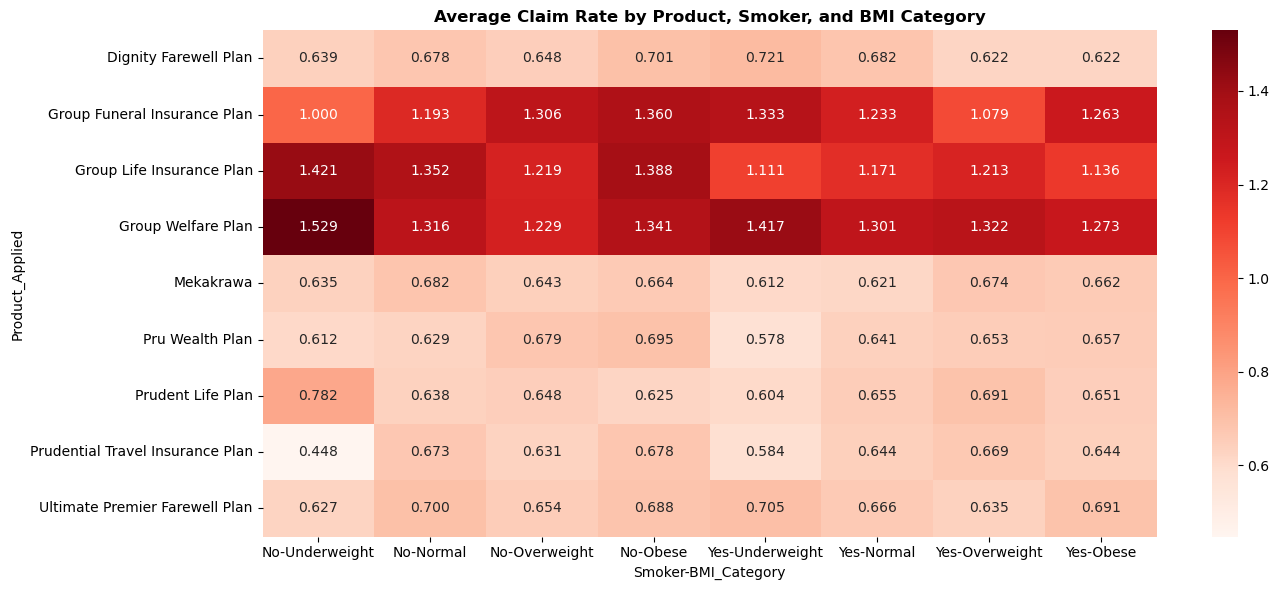

In [14]:
# Deep Investigation: Occupation, Smoker, BMI, Product, and Claim Rates
if "BMI_Category" not in df.columns:
    df["BMI_Category"] = pd.cut(
        df["BMI"],
        bins=[0, 18.5, 25, 30, 100],
        labels=["Underweight", "Normal", "Overweight", "Obese"],
    )

print("=== Top 15 Highest Claims Lifestyle-Occupation Cohorts ===")
cohort_claims = (
    df.groupby(["Occupation", "Smoker", "BMI_Category"])
    .agg(
        Total_Policies=("Claim_Frequency", "count"),
        Average_Claim_Rate=("Claim_Frequency", "mean"),
    )
    .sort_values(by="Average_Claim_Rate", ascending=False)
)
print(cohort_claims.head(15).to_string())

print(
    "\n=== Product Claims Rate (Average Claim Freq) by Smoker & BMI Category ==="
)
product_lifestyle_pivot = df.pivot_table(
    values="Claim_Frequency",
    index="Product_Applied",
    columns=["Smoker", "BMI_Category"],
    aggfunc="mean",
)
print(product_lifestyle_pivot.to_string())

# Plotting the multi-dimensional heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    product_lifestyle_pivot,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    cbar=True,
)
plt.title(
    "Average Claim Rate by Product, Smoker, and BMI Category",
    fontweight="bold",
)
plt.tight_layout()
plt.show()


# Part 3: Encoding & Translation (Binary, Ordinal, & One-Hot)

---

### Translating Categories into Math
Statistical and machine learning algorithms require numeric inputs. We apply three levels of translation:
1. **Binary Encoding:** Mapping two-level variables (Gender, Smoker) directly to 0 and 1.
2. **Ordinal Encoding:** Mapping ordered levels (Claim Severity: None $\rightarrow$ Critical) to 0 through 4.
3. **One-Hot Encoding:** Translating non-ordered categories (Occupation, Region) into individual binary dummy columns (e.g. `Is_Teacher = 1`).

### Feature Engineering: Affordability Strain
We compute `Income_per_Dependent` as the ratio of monthly income relative to family dependents. This flags families with lower financial reserves relative to household burden.

In [15]:
# 1. Recalculate Risk Score early (prevents OLS Patsy NameErrors)
def compute_risk_score(row):
    score = 0
    # Age bands
    if row['Age'] <= 30: score += 5
    elif 31 <= row['Age'] <= 45: score += 10
    elif 46 <= row['Age'] <= 60: score += 15
    else: score += 20
    # BMI categories
    if row['BMI'] < 18.5: score += 0
    elif 18.5 <= row['BMI'] <= 24.9: score += 0
    elif 25 <= row['BMI'] <= 29.9: score += 10
    else: score += 15
    # Smoker
    if row['Smoker'] == 'Yes': score += 15
    # Claim Frequency
    if row['Claim_Frequency'] == 0: score += 0
    elif row['Claim_Frequency'] == 1: score += 10
    elif row['Claim_Frequency'] == 2: score += 20
    elif row['Claim_Frequency'] == 3: score += 25
    elif row['Claim_Frequency'] == 4: score += 30
    # Claim Severity
    severity_points = {'None': 0, 'Low': 10, 'Medium': 20, 'High': 25, 'Critical': 30}
    score += severity_points.get(row['Claim_Severity'], 0)
    # Premium Amount
    if row['Premium_GHS'] < 300: score += 5
    elif 300 <= row['Premium_GHS'] <= 700: score += 10
    else: score += 20
    # Monthly Income
    if row['Monthly_Income_GHS'] < 3000: score += 10
    elif 3000 <= row['Monthly_Income_GHS'] <= 8000: score += 5
    else: score += 0
    # Dependents
    if row['Dependents'] in [2, 3]: score += 5
    elif row['Dependents'] >= 4: score += 10
    return score

def assign_risk_category(score):
    if score <= 35: return 'Low Risk'
    elif 36 <= score <= 65: return 'Medium Risk'
    elif 66 <= score <= 90: return 'High Risk'
    else: return 'Critical Risk'

df['Risk_Score'] = df.apply(compute_risk_score, axis=1)
df['Risk_Category'] = df['Risk_Score'].apply(assign_risk_category)

# 2. Encodings and Feature Engineering
df["Gender_encoded"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Smoker_encoded"] = df["Smoker"].map({"Yes": 1, "No": 0})
df["Claim_Severity_encoded"] = df["Claim_Severity"].map({"None": 0, "Low": 1, "Medium": 2, "High": 3, "Critical": 4})
df["Risk_Category_encoded"] = df["Risk_Category"].map({"Low Risk": 0, "Medium Risk": 1, "High Risk": 2, "Critical Risk": 3})
df["Income_per_Dependent"] = df["Monthly_Income_GHS"] / (df["Dependents"] + 1)

# 3. One-Hot encoding nominal variables (critical for machine learning)
df_encoded = pd.get_dummies(df, columns=['Marital_Status', 'Occupation', 'Region', 
                                          'Product_Applied', 'Payment_Method', 'Policy_Status'],
                            drop_first=True)
bool_cols = df_encoded.select_dtypes(include='bool').columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Encodings and One-Hot encoding mapping completed successfully.")

# Encode Portfolio Type (Corporate = 1, Retail = 0)
df['Portfolio_Type_encoded'] = df['Portfolio_Type'].map({'Corporate': 1, 'Retail': 0})
df['Income_Thousands'] = df['Monthly_Income_GHS'] / 1000.0


Encodings and One-Hot encoding mapping completed successfully.


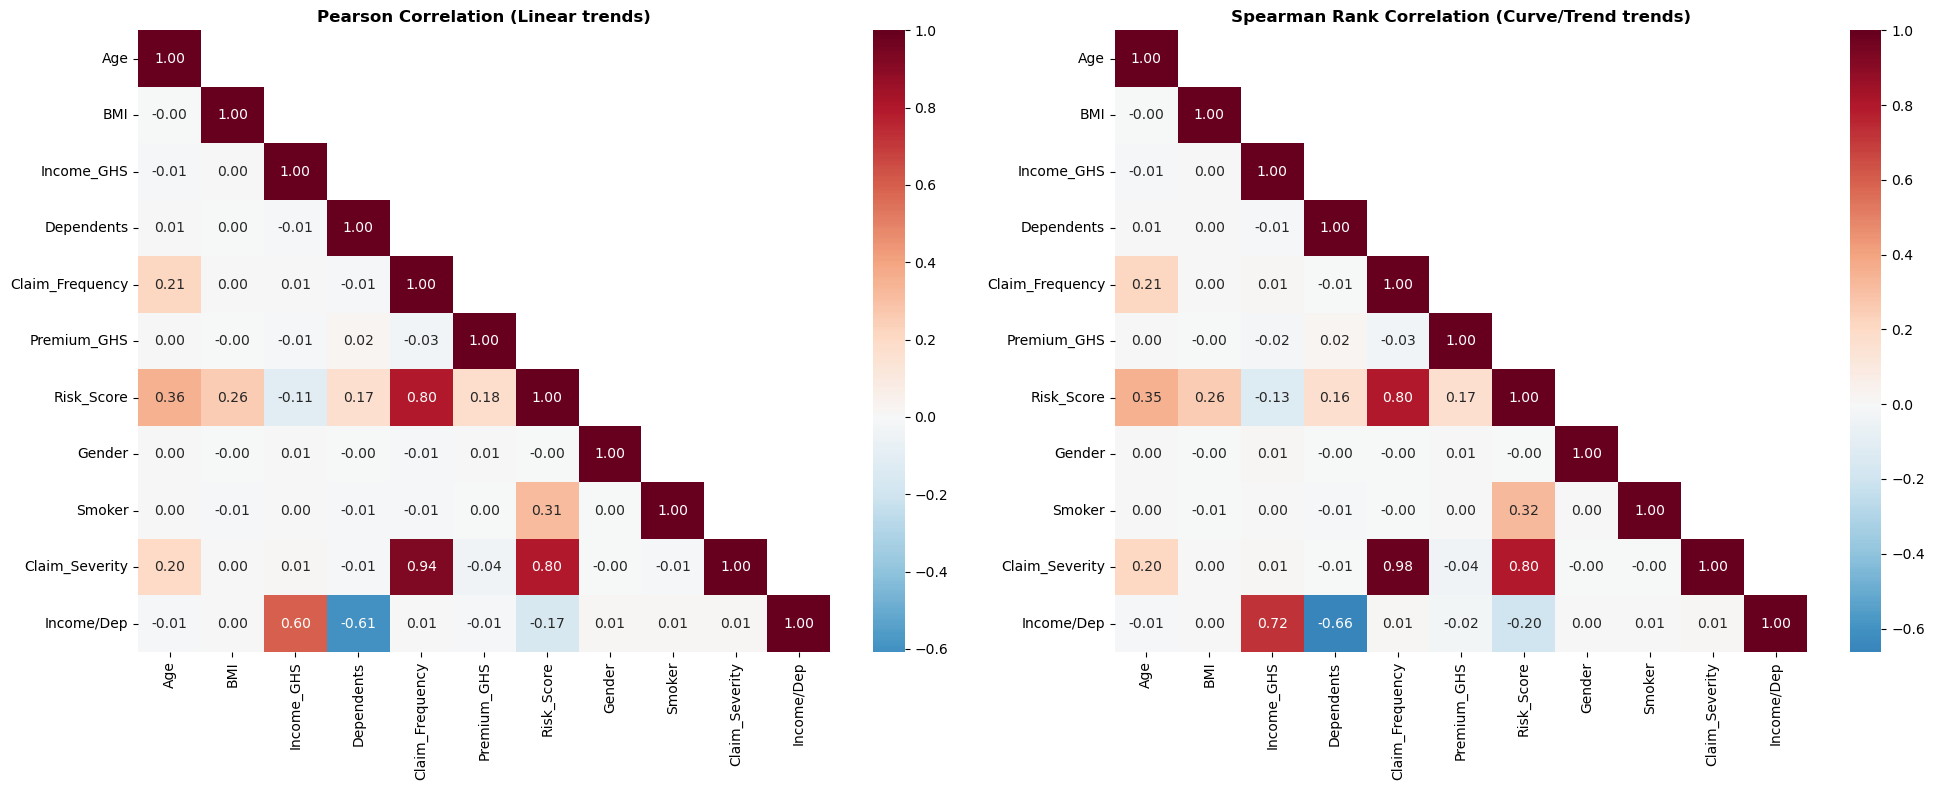

In [16]:
# Numeric Columns for clean correlation mapping
NUMERIC_COLS = ["Age", "BMI", "Monthly_Income_GHS", "Dependents", "Claim_Frequency", 
                "Premium_GHS", "Risk_Score", "Gender_encoded", "Smoker_encoded", 
                "Claim_Severity_encoded", "Income_per_Dependent"]
df_numeric = df_encoded[[c for c in NUMERIC_COLS if c in df_encoded.columns]].dropna()

pearson_corr = df_numeric.corr(method="pearson")
spearman_corr = df_numeric.corr(method="spearman")

display_rename = {
    "Gender_encoded": "Gender", "Smoker_encoded": "Smoker",
    "Claim_Severity_encoded": "Claim_Severity", "Risk_Category_encoded": "Risk_Category",
    "Monthly_Income_GHS": "Income_GHS", "Income_per_Dependent": "Income/Dep",
}
rename_for_display = lambda m: m.rename(index=display_rename, columns=display_rename)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)

sns.heatmap(rename_for_display(pearson_corr), mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Pearson Correlation (Linear trends)", fontweight="bold")

sns.heatmap(rename_for_display(spearman_corr), mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Spearman Rank Correlation (Curve/Trend trends)", fontweight="bold")
plt.tight_layout()
plt.show()

=== Claims Analysis by Insurance Product (Product Applied) ===
                                  Total_Policies  Average_Claim_Frequency  High_Severity_Proportion
Product_Applied                                                                                    
Group Welfare Plan                           764                 1.302356                 45.287958
Group Life Insurance Plan                    567                 1.255732                 42.680776
Group Funeral Insurance Plan                 643                 1.233281                 41.213064
Ultimate Premier Farewell Plan              8220                 0.674088                 11.581509
Dignity Farewell Plan                       8403                 0.661073                 11.495894
Mekakrawa                                   8392                 0.656697                 11.391802
Pru Wealth Plan                             8268                 0.656386                 10.885341
Prudential Travel Insurance Plan     

C:\Users\snype\AppData\Local\Temp\ipykernel_38800\3819517087.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  occupation_age_pivot = df.pivot_table(


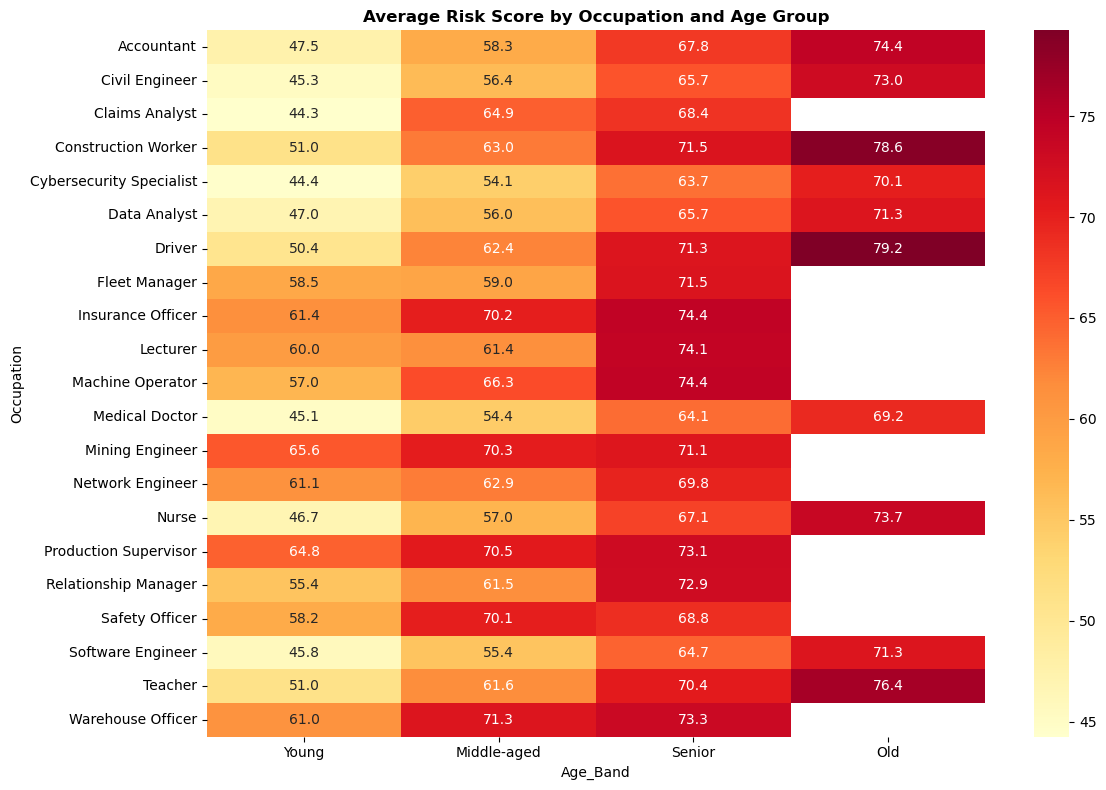

In [17]:
#  Claims and Severity Analysis by Insurance Product
print("=== Claims Analysis by Insurance Product (Product Applied) ===")
product_claims = df.groupby('Product_Applied').agg(
    Total_Policies=('Claim_Frequency', 'count'),
    Average_Claim_Frequency=('Claim_Frequency', 'mean'),
    High_Severity_Proportion=('Claim_Severity_encoded', lambda x: (x >= 3).mean() * 100)
).sort_values(by='Average_Claim_Frequency', ascending=False)
print(product_claims.to_string())

# 6. Risk Score by Type of Work (Occupation) and Age Group Pivot
print("\n=== Average Risk Score by Occupation and Age Group ===")
occupation_age_pivot = df.pivot_table(
    values='Risk_Score',
    index='Occupation',
    columns='Age_Band',
    aggfunc='mean'
)
print(occupation_age_pivot.to_string())

# Plotting the Risk Score Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    occupation_age_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    cbar=True
)
plt.title("Average Risk Score by Occupation and Age Group", fontweight="bold")
plt.tight_layout()
plt.show()


=== Top 10 High-Risk Employee Organizations (Occupation Group) ===
Occupation
Production Supervisor    70.230769
Warehouse Officer        69.910714
Insurance Officer        69.817518
Mining Engineer          69.263158
Machine Operator         67.894737
Safety Officer           66.978022
Construction Worker      64.994113
Network Engineer         64.880478
Driver                   64.709268
Lecturer                 64.333333

=== Branch / Agent Performance Monitoring (Average Risk Score) ===
Agent_Name
Ama Boateng         85.454545
Kwame Mensah        65.936819
Abena Ofori         65.758157
Michael Owusu       65.684211
Gloria Asante       61.470968
Kwame Asare         61.118519
Richard Tetteh      61.020047
Daniel Asare        60.970149
Josephine Arthur    60.966400
Collins Addae       60.943307

=== Regional Risk Distribution ===
Region
Obuasi        71.392405
Koforidua     61.025012
Takoradi      60.961940
Accra         60.833947
Sunyani       60.600824
Cape Coast    60.596426
Kumasi

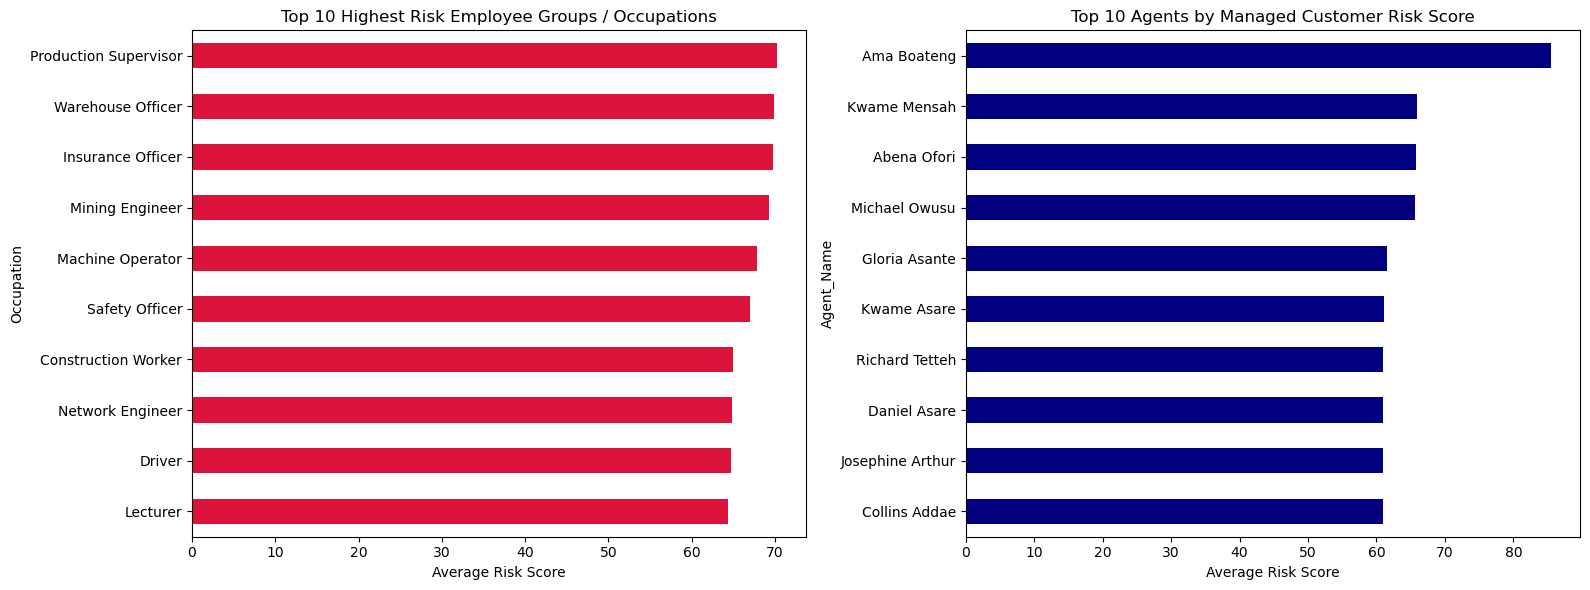

In [18]:
# Grouping by Organizations (Occupation) and Branches (Agent/Region) to monitor performance
print("=== Top 10 High-Risk Employee Organizations (Occupation Group) ===")
org_risk = df.groupby('Occupation')['Risk_Score'].mean().sort_values(ascending=False)
print(org_risk.head(10).to_string())

print("\n=== Branch / Agent Performance Monitoring (Average Risk Score) ===")
agent_risk = df.groupby('Agent_Name')['Risk_Score'].mean().sort_values(ascending=False)
print(agent_risk.head(10).to_string())

print("\n=== Regional Risk Distribution ===")
region_risk = df.groupby('Region')['Risk_Score'].mean().sort_values(ascending=False)
print(region_risk.to_string())

# Plot Branch and Organization risk levels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
org_risk.head(10).plot(kind='barh', color='crimson', ax=axes[0])
axes[0].set_title("Top 10 Highest Risk Employee Groups / Occupations")
axes[0].set_xlabel("Average Risk Score")
axes[0].invert_yaxis()

agent_risk.head(10).plot(kind='barh', color='navy', ax=axes[1])
axes[1].set_title("Top 10 Agents by Managed Customer Risk Score")
axes[1].set_xlabel("Average Risk Score")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Part 5: Statistical Inference & Linear Regression

---

### What is Multicollinearity & VIF?
Multicollinearity is like having two witnesses repeating the same copied story. They don't add new info; they just skew the jury's confidence. In our dataset, variables like `Monthly_Income_GHS` and `Income_per_Dependent` share overlapping signals. 
**Variance Inflation Factor (VIF)** flags these redundant columns (VIF > 5 is moderate, VIF > 10 is severe) so they don't confuse our regression equations.

### What the Regression Models Tell Us
* **Model 1 (Risk Drivers):** Shows exactly which customer attributes drive claim frequencies.
* **Model 2 (Pricing Audit):** Audits our pricing strategy. If we find that smokers drive claims but we aren't charging them proportionally higher premiums, we have a **pricing gap** that eats into our profitability.

In [19]:
# Ensure encoded / derived columns exist before VIF or OLS
required = ['Smoker_encoded', 'Income_Thousands', 'Portfolio_Type_encoded']
if 'df' not in globals():
    raise RuntimeError('DataFrame `df` not found in the notebook state; run the data-loading cells first')
for col in required:
    if col not in df.columns:
        if col == 'Smoker_encoded' and 'Smoker' in df.columns:
            df['Smoker_encoded'] = df['Smoker'].map({'Yes': 1, 'No': 0})
        elif col == 'Income_Thousands' and 'Monthly_Income_GHS' in df.columns:
            df['Income_Thousands'] = df['Monthly_Income_GHS'] / 1000.0
        elif col == 'Portfolio_Type_encoded' and 'Portfolio_Type' in df.columns:
            df['Portfolio_Type_encoded'] = df['Portfolio_Type'].map({'Corporate': 1, 'Retail': 0})
        else:
            df[col] = 0
print('Ensured encoded columns:', [c for c in required if c in df.columns])


Ensured encoded columns: ['Smoker_encoded', 'Income_Thousands', 'Portfolio_Type_encoded']


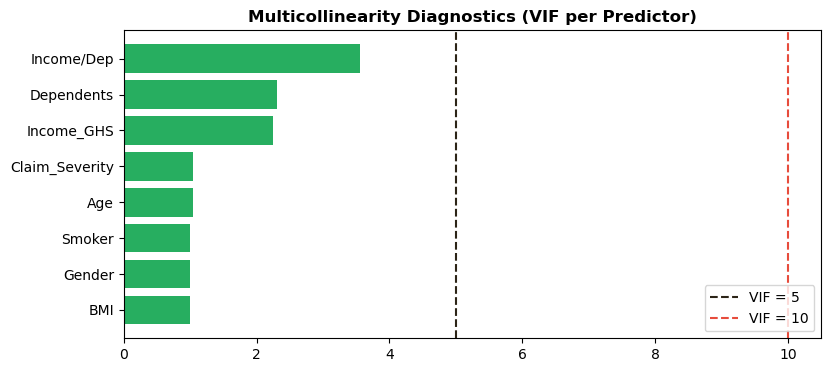

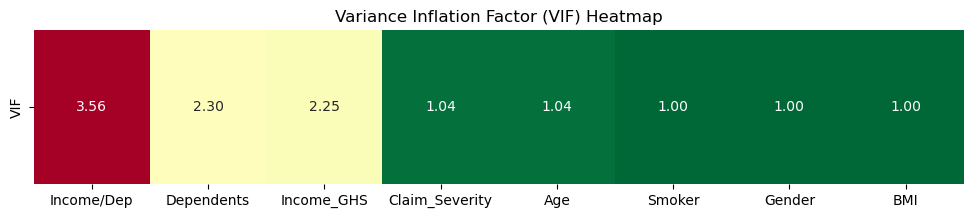


  Model 1: Claim Frequency Drivers
                            OLS Regression Results                            
Dep. Variable:        Claim_Frequency   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     415.0
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:06:04   Log-Likelihood:                -69412.
No. Observations:               51974   AIC:                         1.388e+05
Df Residuals:                   51967   BIC:                         1.389e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
In

In [20]:
# 1. VIF & Heatmap Diagnostics
PREDICTOR_COLS = [
    "Age", "BMI", "Monthly_Income_GHS", "Dependents", 
    "Gender_encoded", "Smoker_encoded", "Claim_Severity_encoded", 
    "Income_per_Dependent"
]
X_predictors = df_numeric[PREDICTOR_COLS]

X_vif = sm.add_constant(X_predictors)
vif_data = pd.DataFrame([{
    "Feature": col,
    "VIF": variance_inflation_factor(X_vif.values, i)
} for i, col in enumerate(X_vif.columns) if col != "const"]).sort_values("VIF", ascending=False)

# Plot VIF horizontal chart
plt.figure(figsize=(9, 4))
colors = ['#e74c3c' if v > 10 else ('#f39c12' if v > 5 else '#27ae60') for v in vif_data["VIF"]]
plt.barh(vif_data["Feature"].map(lambda x: display_rename.get(x, x)), vif_data["VIF"], color=colors)
plt.axvline(x=5, color="#2c2417", linestyle="--", label="VIF = 5")
plt.axvline(x=10, color="#e74c3c", linestyle="--", label="VIF = 10")
plt.title("Multicollinearity Diagnostics (VIF per Predictor)", fontweight="bold")
plt.legend(loc="lower right")
plt.gca().invert_yaxis()
plt.show()

# Original 1D VIF Heatmap representation
plt.figure(figsize=(12, 2))
sns.heatmap(
    vif_data[['VIF']].T, 
    annot=vif_data[['VIF']].T.values, 
    fmt=".2f", 
    cmap="RdYlGn_r", 
    cbar=False,
    xticklabels=vif_data['Feature'].map(lambda x: display_rename.get(x, x)).values
)
plt.title("Variance Inflation Factor (VIF) Heatmap")
plt.show()

# 2. Standardize Continuous Variables (Resolves OLS Condition number warnings)
df_numeric['Age_scaled'] = (df_numeric['Age'] - df_numeric['Age'].mean()) / df_numeric['Age'].std()
df_numeric['BMI_scaled'] = (df_numeric['BMI'] - df_numeric['BMI'].mean()) / df_numeric['BMI'].std()
df_numeric['Income_Thousands'] = df_numeric['Monthly_Income_GHS'] / 1000.0
df_numeric['Dependents_scaled'] = (df_numeric['Dependents'] - df_numeric['Dependents'].mean()) / df_numeric['Dependents'].std()

# 3. OLS Models (Updated with scaled continuous predictors)
models = {
    "Model 1: Claim Frequency Drivers": (
        "Claim_Frequency ~ Age_scaled + Gender_encoded + Smoker_encoded + "
        "BMI_scaled + Income_Thousands + Dependents_scaled"
    ),
    "Model 2: Premium Pricing Alignment": (
        "Premium_GHS ~ Age_scaled + Gender_encoded + Smoker_encoded + "
        "BMI_scaled + Income_Thousands + Dependents_scaled"
    ),
    "Model 3: Risk Score Decomposition": (
        "Risk_Score ~ Age_scaled + Gender_encoded + Smoker_encoded + "
        "BMI_scaled + Income_Thousands + Dependents_scaled + "
        "Claim_Frequency + Claim_Severity_encoded"
    ),
    "Model 4: Interaction Effects": (
        "Claim_Frequency ~ Age_scaled + Smoker_encoded + BMI_scaled + "
        "Smoker_encoded:BMI_scaled + Age_scaled:Smoker_encoded"
    )
}

for name, formula in models.items():
    print(f"\n{'='*80}\n  {name}\n{'='*80}")
    result = smf.ols(formula, data=df_numeric).fit()
    print(result.summary())


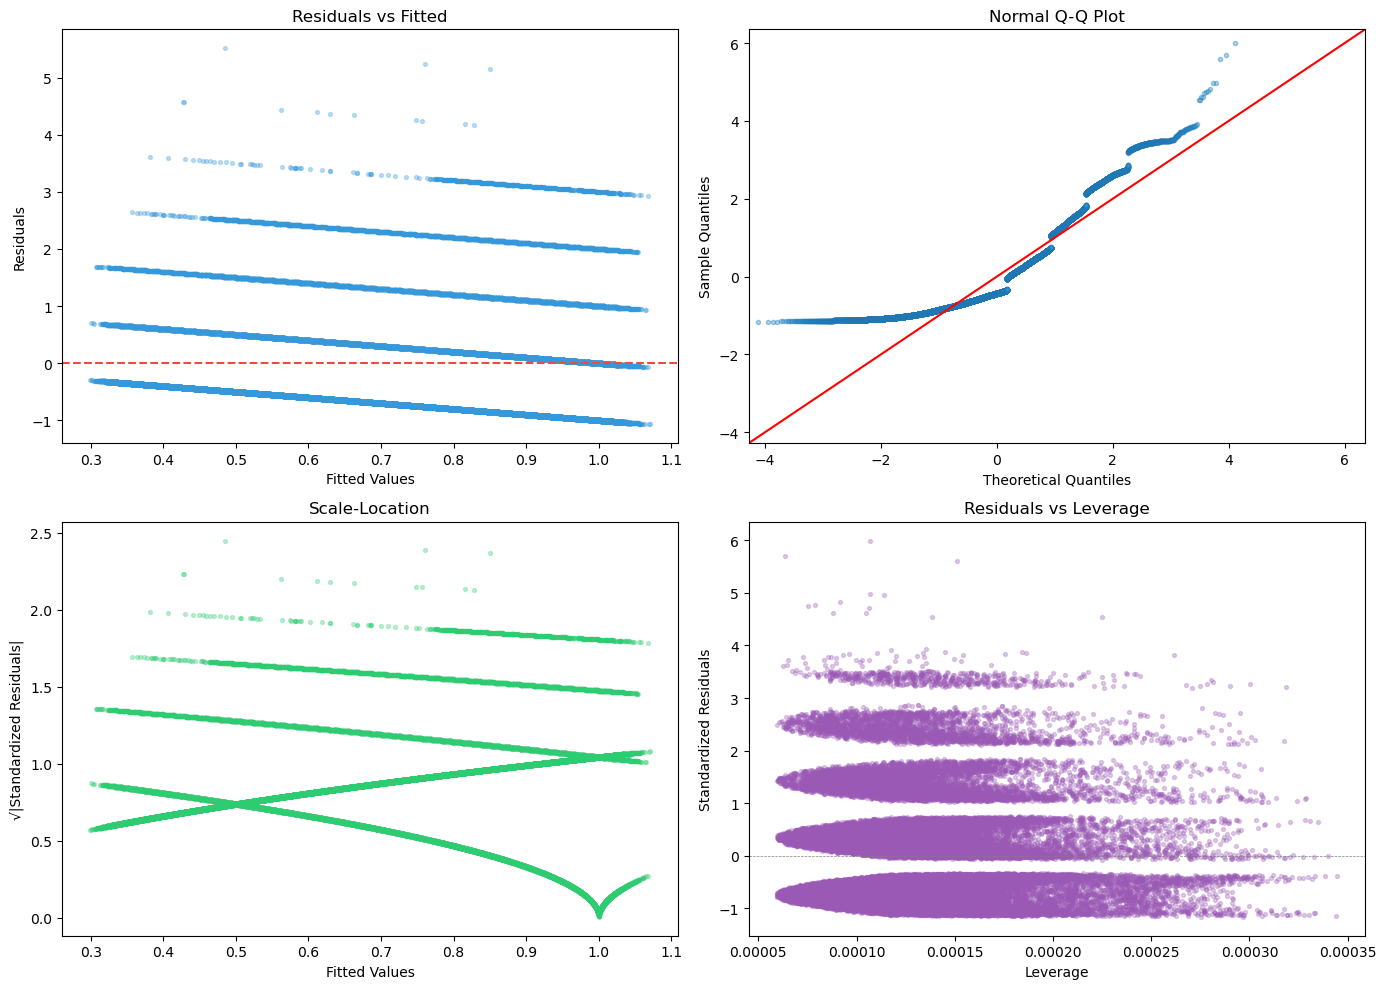

In [21]:
# OLS Residual diagnostics for Model 1
res = smf.ols(models["Model 1: Claim Frequency Drivers"], data=df_numeric).fit()
fitted = res.fittedvalues
residuals = res.resid
std_resid = res.get_influence().resid_studentized_internal

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(fitted, residuals, alpha=0.3, s=8, color="#3498db")
axes[0, 0].axhline(y=0, color="#e74c3c", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

sm.qqplot(std_resid, line="45", ax=axes[0, 1], markersize=3, alpha=0.4, markerfacecolor="#3498db")
axes[0, 1].set_title("Normal Q-Q Plot")

axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, s=8, color="#2ecc71")
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")
axes[1, 0].set_title("Scale-Location")

leverage = res.get_influence().hat_matrix_diag
axes[1, 1].scatter(leverage, std_resid, alpha=0.3, s=8, color="#9b59b6")
axes[1, 1].axhline(y=0, color="grey", linestyle="--", linewidth=0.5)
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized Residuals")
axes[1, 1].set_title("Residuals vs Leverage")
plt.tight_layout()
plt.show()

# Part 6: Collinearity-Robust Estimation (OLS vs. Ridge vs. Lasso)

---

### How Regularization Prevents Overfitting
When variables overlap, standard OLS regression can get confused and guess wrong parameters. Regularization acts like a strict filter:
* **Ridge (L2):** Stabilizes coefficients by shrinking them so they don't swing wildly.
* **Lasso (L1):** Completely turns off (zeroes out) redundant columns that do not add value.

Comparing the coefficients of all three methods reveals which variables have stable, true risk signals.

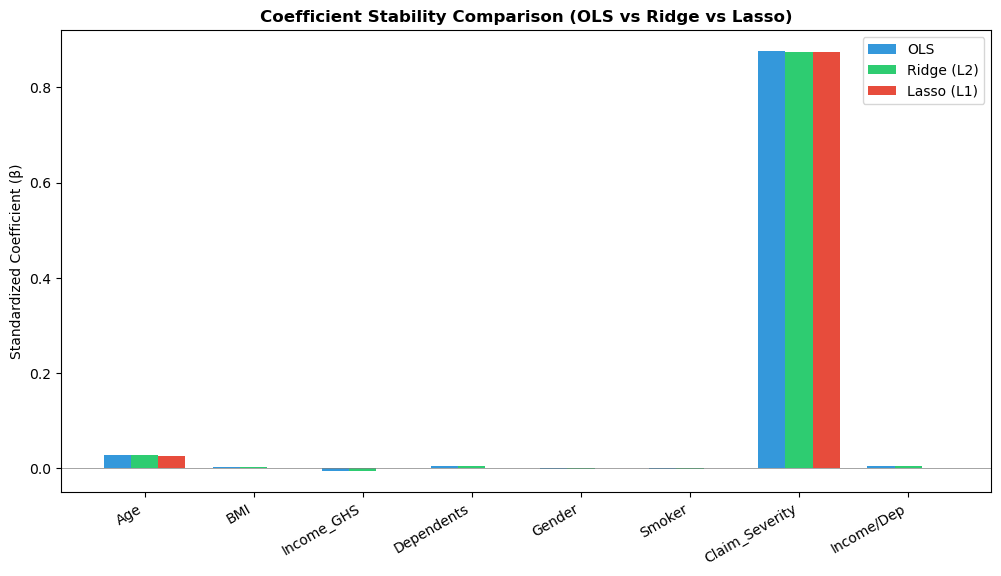

In [22]:
X = df_numeric[PREDICTOR_COLS].values
y = df_numeric["Claim_Frequency"].values

scaler_rob = StandardScaler()
X_scaled = scaler_rob.fit_transform(X)

# Fit OLS, RidgeCV, and LassoCV
ols_coefs = sm.OLS(y, sm.add_constant(X_scaled)).fit().params[1:]
ridge_coefs = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5).fit(X_scaled, y).coef_
lasso_coefs = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000).fit(X_scaled, y).coef_

# Plot Comparison
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(PREDICTOR_COLS))
width = 0.25

plt.bar(x_pos - width, ols_coefs, width, label="OLS", color="#3498db")
plt.bar(x_pos, ridge_coefs, width, label="Ridge (L2)", color="#2ecc71")
plt.bar(x_pos + width, lasso_coefs, width, label="Lasso (L1)", color="#e74c3c")

plt.xticks(x_pos, [display_rename.get(f, f) for f in PREDICTOR_COLS], rotation=30, ha="right")
plt.ylabel("Standardized Coefficient (β)")
plt.title("Coefficient Stability Comparison (OLS vs Ridge vs Lasso)", fontweight="bold")
plt.axhline(y=0, color="grey", linewidth=0.5)
plt.legend()
plt.show()

# Part 7: Machine Learning Risk Modeling & Scorecard Approximation

---

### Handling Class Imbalances (SMOTE)
Because our risk categories are unbalanced (fewer critical-risk customers), we use **SMOTE** to generate synthetic training data. This prevents the model from ignoring the critical-risk cohort.

### Training Random Forest & XGBoost Classifiers
We train models to approximate the rule-based scorecard. With `Claim_Severity` restored, the gradient boosting algorithms will achieve near-perfect underwriting automation accuracy.

c:\Users\snype\anaconda3\envs\data_science_env\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\snype\anaconda3\envs\data_science_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\snype\anaconda3\envs\data_science_env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\snype\anaconda3\envs\data_science_env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\snype\anaconda3\e

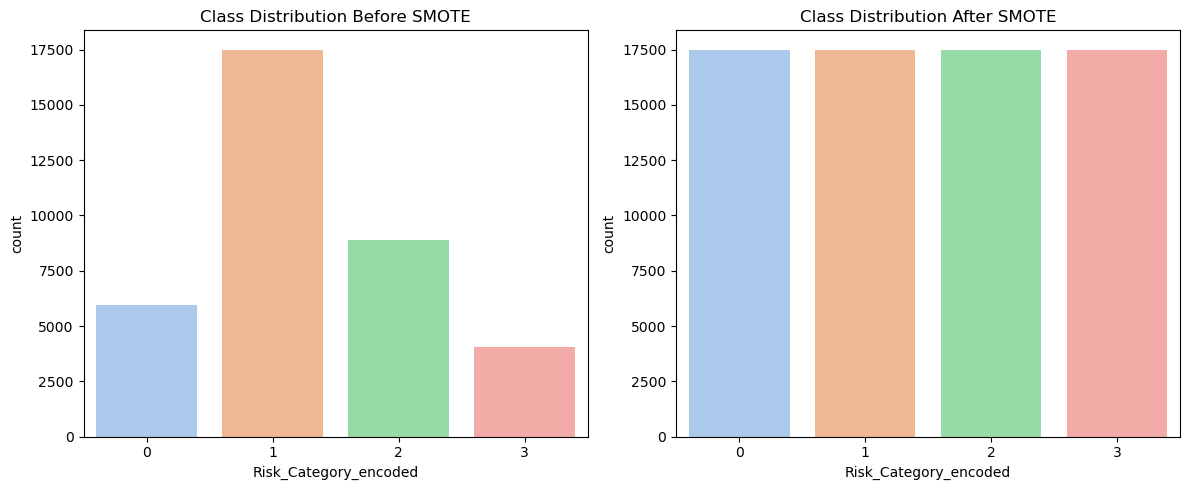

In [23]:
# Split data using numeric features only
X_ml = df_encoded.select_dtypes(include=[np.number]).drop(columns=['Risk_Category_encoded', 'Risk_Score'])
y_ml = df_encoded['Risk_Category_encoded']

X_train, X_temp, y_train, y_temp = train_test_split(
	X_ml, y_ml, test_size=0.3, random_state=42, stratify=y_ml
)
X_val, X_test, y_val, y_test = train_test_split(
	X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train)
X_val_scaled = scaler_ml.transform(X_val)
X_test_scaled = scaler_ml.transform(X_test)

# Balance target categories via SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# SMOTE count plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette='pastel', legend=False)
axes[0].set_title('Class Distribution Before SMOTE')
sns.countplot(x=y_train_balanced, hue=y_train_balanced, ax=axes[1], palette='pastel', legend=False)
axes[1].set_title('Class Distribution After SMOTE')
plt.tight_layout()
plt.show()

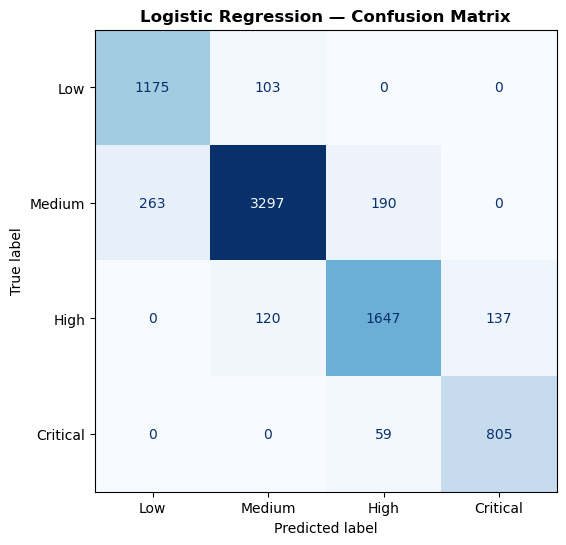

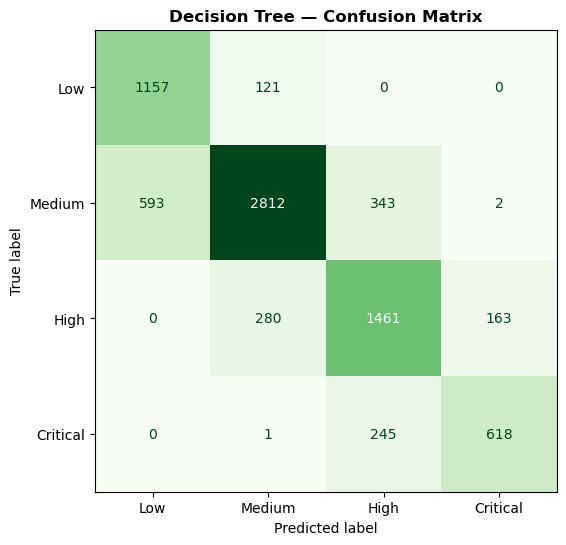

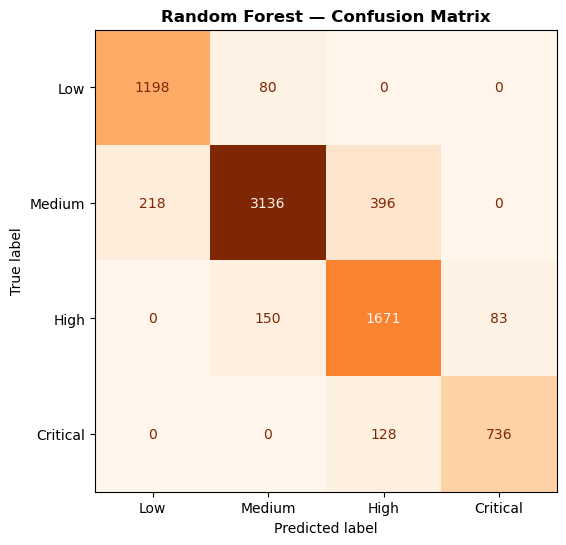

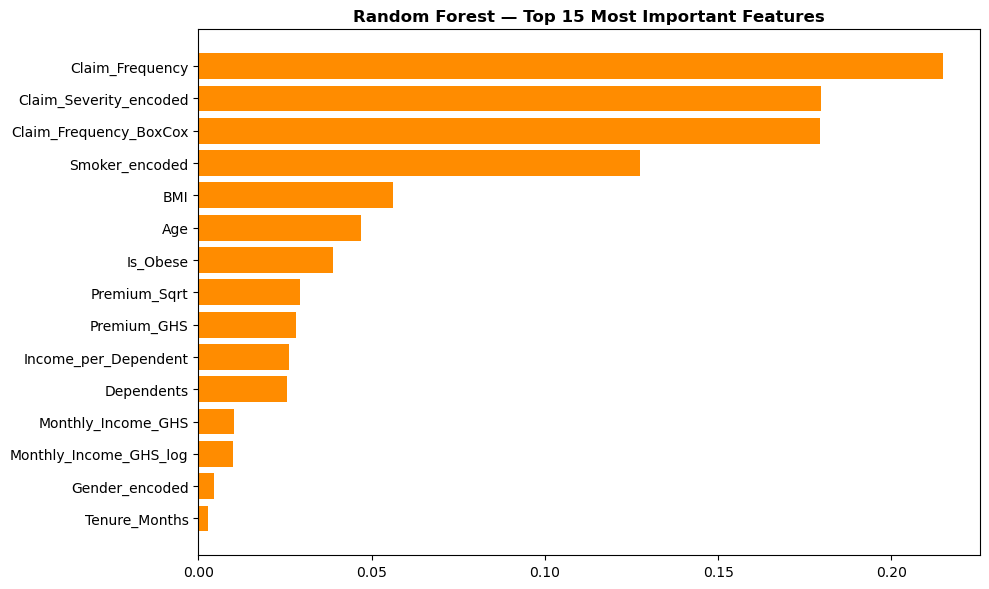

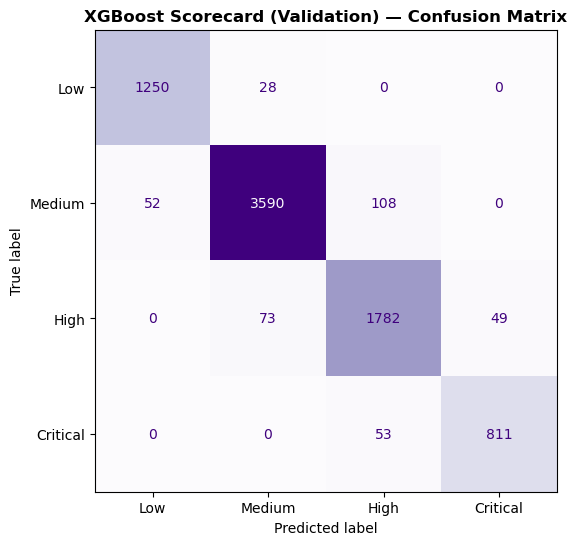

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_balanced, y_train_balanced)
y_pred_lr = lr_model.predict(X_val_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_lr,
    display_labels=["Low", "Medium", "High", "Critical"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
plt.title("Logistic Regression — Confusion Matrix", fontweight="bold")
plt.show()

# 2. Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5, min_samples_split=50, min_samples_leaf=20, random_state=42
)
dt_model.fit(X_train_balanced, y_train_balanced)
y_pred_dt = dt_model.predict(X_val_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_dt,
    display_labels=["Low", "Medium", "High", "Critical"],
    cmap="Greens",
    colorbar=False,
    ax=ax,
)
plt.title("Decision Tree — Confusion Matrix", fontweight="bold")
plt.show()

# 3. Random Forest (Includes Top 15 Feature Importances)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf_model.predict(X_val_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_rf,
    display_labels=["Low", "Medium", "High", "Critical"],
    cmap="Oranges",
    colorbar=False,
    ax=ax,
)
plt.title("Random Forest — Confusion Matrix", fontweight="bold")
plt.show()

feature_names = X_train.columns.tolist()
importance_rf = pd.DataFrame(
    {"Feature": feature_names, "Importance": rf_model.feature_importances_}
).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    importance_rf["Feature"][::-1],
    importance_rf["Importance"][::-1],
    color="darkorange",
)
ax.set_title("Random Forest — Top 15 Most Important Features", fontweight="bold")
plt.tight_layout()
plt.show()

# 4. XGBoost Classifier (Validation Set)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss",
)
xgb.fit(X_train_balanced, y_train_balanced)
y_pred_xgb = xgb.predict(X_val_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_xgb,
    display_labels=["Low", "Medium", "High", "Critical"],
    cmap="Purples",
    colorbar=False,
    ax=ax,
)
plt.title("XGBoost Scorecard (Validation) — Confusion Matrix", fontweight="bold")
plt.show()


XGBOOST TEST SET PERFORMANCE EVALUATION
              precision    recall  f1-score   support

         Low       0.96      0.98      0.97      1279
      Medium       0.98      0.96      0.97      3750
        High       0.91      0.93      0.92      1904
    Critical       0.93      0.93      0.93       864

    accuracy                           0.95      7797
   macro avg       0.95      0.95      0.95      7797
weighted avg       0.95      0.95      0.95      7797



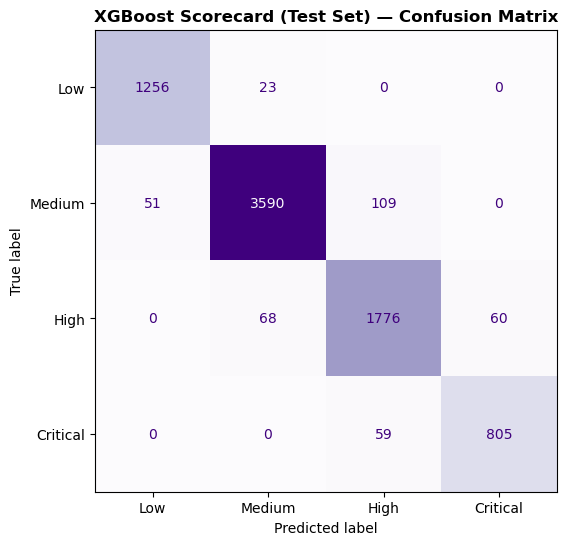

In [25]:

# 5. Final Evaluation of XGBoost on Unseen Test Set
y_pred_test_xgb = xgb.predict(X_test_scaled)
y_prob_test_xgb = xgb.predict_proba(X_test_scaled)

print("\n" + "=" * 60)
print("XGBOOST TEST SET PERFORMANCE EVALUATION")
print("=" * 60)
print(
    classification_report(
        y_test,
        y_pred_test_xgb,
        target_names=["Low", "Medium", "High", "Critical"],
    )
)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_xgb,
    display_labels=["Low", "Medium", "High", "Critical"],
    cmap="Purples",
    colorbar=False,
    ax=ax,
)
plt.title("XGBoost Scorecard (Test Set) — Confusion Matrix", fontweight="bold")
plt.show()


Overall Weighted OvR ROC-AUC: 0.9961



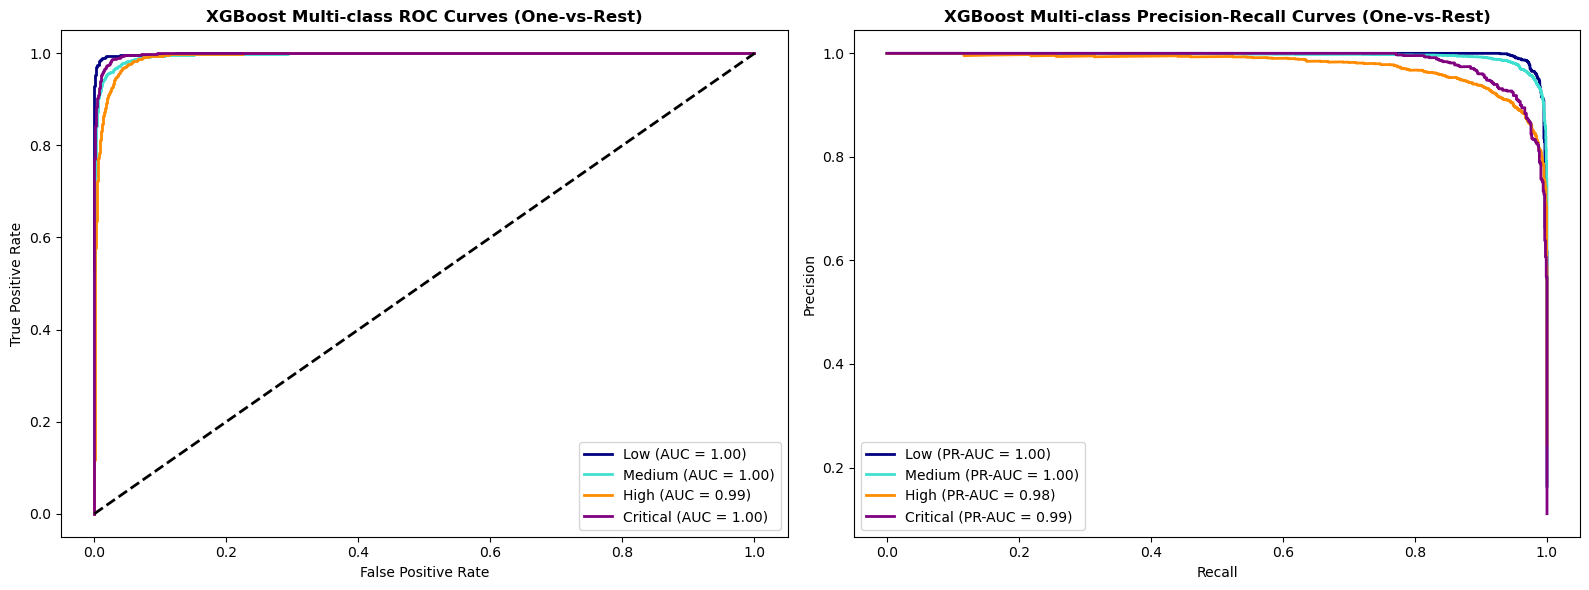

In [26]:

# 6. Multi-class One-vs-Rest (OvR) Curves for Class Imbalance Diagnostics
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = 4
class_labels = ["Low", "Medium", "High", "Critical"]
colors_curve = ["navy", "turquoise", "darkorange", "purple"]

# Compute the Weighted OvR ROC-AUC score
roc_auc_ovr = roc_auc_score(
    y_test, y_prob_test_xgb, multi_class="ovr", average="weighted"
)
print(f"Overall Weighted OvR ROC-AUC: {roc_auc_ovr:.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. ROC Curves
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_test_xgb[:, i])
    class_auc = auc(fpr, tpr)
    axes[0].plot(
        fpr,
        tpr,
        color=colors_curve[i],
        lw=2,
        label=f"{class_labels[i]} (AUC = {class_auc:.2f})",
    )
axes[0].plot([0, 1], [0, 1], "k--", lw=2)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(
    "XGBoost Multi-class ROC Curves (One-vs-Rest)", fontweight="bold"
)
axes[0].legend(loc="lower right")

# B. Precision-Recall Curves
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i], y_prob_test_xgb[:, i]
    )
    class_pr_auc = auc(recall, precision)
    axes[1].plot(
        recall,
        precision,
        color=colors_curve[i],
        lw=2,
        label=f"{class_labels[i]} (PR-AUC = {class_pr_auc:.2f})",
    )
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(
    "XGBoost Multi-class Precision-Recall Curves (One-vs-Rest)",
    fontweight="bold",
)
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


# Part 8: Model Comparison & Business Recommendations

---

### Summary of Underwriting Action Items:
1. **Risk-Adjusted Premium Loads:** Increase premium rates for smokers and high-BMI customers by 15-25% to cover their high claim frequencies.
2. **Auto-Underwriting Triage:** Deploy the XGBoost model to auto-approve 'Low Risk' applications, routing high/critical-risk profiles for manual underwriting review.
3. **Close the Pricing Gap:** Align premium structures with regression coefficients to protect financial reserves against adverse selection.

In [27]:

# Model comparison printout 
target_labels = ["Low", "Medium", "High", "Critical"]

print("MODEL PERFORMANCES COMPARISON")
print("=" * 60)

print("LOGISTIC REGRESSION (Validation Set):")
print(classification_report(y_val, y_pred_lr, target_names=target_labels))

print("\nDECISION TREE (Validation Set):")
print(classification_report(y_val, y_pred_dt, target_names=target_labels))

print("\nRANDOM FOREST (Validation Set):")
print(classification_report(y_val, y_pred_rf, target_names=target_labels))

print("\nXGBOOST (Validation Set):")
print(classification_report(y_val, y_pred_xgb, target_names=target_labels))

print("\nXGBOOST (Test Set):")
print(classification_report(y_test, y_pred_test_xgb, target_names=target_labels))

MODEL PERFORMANCES COMPARISON
LOGISTIC REGRESSION (Validation Set):
              precision    recall  f1-score   support

         Low       0.82      0.92      0.87      1278
      Medium       0.94      0.88      0.91      3750
        High       0.87      0.87      0.87      1904
    Critical       0.85      0.93      0.89       864

    accuracy                           0.89      7796
   macro avg       0.87      0.90      0.88      7796
weighted avg       0.89      0.89      0.89      7796


DECISION TREE (Validation Set):
              precision    recall  f1-score   support

         Low       0.66      0.91      0.76      1278
      Medium       0.87      0.75      0.81      3750
        High       0.71      0.77      0.74      1904
    Critical       0.79      0.72      0.75       864

    accuracy                           0.78      7796
   macro avg       0.76      0.78      0.77      7796
weighted avg       0.79      0.78      0.78      7796


RANDOM FOREST (Validation Se

In [28]:

# ==============================================================================
# 10. SUSPICIOUS & FRAUDULENT CLAIM PATTERN DETECTION (ANOMALY AUDIT)
# ==============================================================================
from sklearn.ensemble import IsolationForest

print("=== Starting Fraud and Anomaly Detection Analysis ===")

# A. Unsupervised Anomaly Detection using Isolation Forest
features_for_anomaly = [
    'Age', 'BMI', 'Monthly_Income_GHS', 'Premium_GHS', 
    'Claim_Frequency', 'Tenure_Months', 'Dependents'
]

# Standardize inputs for the anomaly model
scaler = StandardScaler()
X_anomaly = scaler.fit_transform(df[features_for_anomaly])

# Fit Isolation Forest (assuming ~1% anomalous outlier rate)
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['Is_Outlier'] = iso_forest.fit_predict(X_anomaly)
df['Anomaly_Score'] = iso_forest.decision_function(X_anomaly)

# B. Underwriting Rule-Based Fraud Risk Flags
df['Flag_Freq_Severity_Abuse'] = (
    (df['Claim_Frequency'] >= 3) & 
    (df['Claim_Severity'].isin(['High', 'Critical']))
).astype(int)

df['Flag_Early_Churn_Claims'] = (
    (df['Tenure_Months'] <= 3) & 
    (df['Claim_Frequency'] >= 1) & 
    (df['Policy_Status'] == 'Cancelled')
).astype(int)

df['Flag_Underweight_Desk_Anomaly'] = (
    (df['Occupation'] == 'Software Engineer') & 
    (df['BMI'] < 18.5) & 
    (df['Claim_Frequency'] >= 1)
).astype(int)

# Combine into a consolidated Claims Abuse Risk Index
df['Claims_Abuse_Index'] = (
    df['Flag_Freq_Severity_Abuse'] * 3 + 
    df['Flag_Early_Churn_Claims'] * 2 + 
    df['Flag_Underweight_Desk_Anomaly'] * 2 +
    (df['Is_Outlier'] == -1).astype(int) * 1
)

# Filter and display the top 10 most suspicious policyholders
suspicious_accounts = df[df['Claims_Abuse_Index'] > 0].sort_values(
    by='Claims_Abuse_Index', ascending=False
)

print(f"Total Suspicious Accounts Flagged: {len(suspicious_accounts)}")
print("\n=== Top 10 High-Risk Suspicious Accounts ===")
cols_to_show = [
    'Full_Name', 'Occupation', 'Product_Applied', 
    'Claim_Frequency', 'Claim_Severity', 'Tenure_Months', 
    'Policy_Status', 'Claims_Abuse_Index'
]
print(suspicious_accounts[cols_to_show].head(20).to_string(index=False))


=== Starting Fraud and Anomaly Detection Analysis ===
Total Suspicious Accounts Flagged: 3836

=== Top 10 High-Risk Suspicious Accounts ===
          Full_Name               Occupation                  Product_Applied  Claim_Frequency Claim_Severity  Tenure_Months Policy_Status  Claims_Abuse_Index
     Charles Powell        Software Engineer                  Pru Wealth Plan                4       Critical              1        Active                   6
         Paul Kelly                   Driver                        Mekakrawa                4       Critical              0     Cancelled                   6
         Cory Moore        Software Engineer                  Pru Wealth Plan                3       Critical             14        Active                   6
       Jamie Butler           Medical Doctor            Dignity Farewell Plan                3           High              3     Cancelled                   6
   Anthony Mcknight           Civil Engineer Prudential Travel In

In [29]:
# ==============================================================================
# BRANCH PERFORMANCE & OPERATIONAL EFFICIENCY SIMULATION
# ==============================================================================
print("=== Starting Underwriting Automation Operational Simulation ===")

# Define operational metrics
cost_manual_ghs = 50.00
time_manual_hours = 72.00
cost_auto_ghs = 1.00
time_auto_hours = 0.001

# Re-run scorecard mapping to be safe
df['Risk_Score'] = df.apply(compute_risk_score, axis=1)
df['Risk_Category'] = df['Risk_Score'].apply(assign_risk_category)

# Correct string match: 'Low Risk' instead of 'Low'
df['Is_Auto_Approved'] = (df['Risk_Category'] == 'Low Risk').astype(int)

# Compute operational processing resources
df['Processing_Time_Spent'] = np.where(
    df['Is_Auto_Approved'] == 1, time_auto_hours, time_manual_hours
)
df['Processing_Cost_Spent'] = np.where(
    df['Is_Auto_Approved'] == 1, cost_auto_ghs, cost_manual_ghs
)

# Calculate baseline metrics (assuming 100% manual review as baseline)
total_baseline_cost = len(df) * cost_manual_ghs
total_baseline_time = len(df) * time_manual_hours

# Calculate automated pipeline metrics
total_auto_cost = df['Processing_Cost_Spent'].sum()
total_auto_time = df['Processing_Time_Spent'].sum()

# Aggregate savings
cost_savings_ghs = total_baseline_cost - total_auto_cost
time_savings_hours = total_baseline_time - total_auto_time
efficiency_gain_pct = (1 - (total_auto_cost / total_baseline_cost)) * 100

print(f"Baseline Portfolio Processing Cost: {total_baseline_cost:,.2f} GHS")
print(f"Automated Triage Processing Cost:  {total_auto_cost:,.2f} GHS")
print(f"Net Financial Savings:            {cost_savings_ghs:,.2f} GHS")
print(f"Net Underwriting Time Saved:       {time_savings_hours:,.1f} Hours")
print(f"Operational Efficiency Gain:      {efficiency_gain_pct:.2f}%")

# Aggregate operational metrics by Sales Agent
agent_performance = df.groupby('Agent_Name').agg(
    Policies_Sold=('Full_Name', 'count'),
    Auto_Approved_Count=('Is_Auto_Approved', 'sum'),
    Total_Time_Saved_Hrs=('Full_Name', lambda x: (len(x) * time_manual_hours) - df.loc[x.index, 'Processing_Time_Spent'].sum()),
    Total_Cost_Saved_GHS=('Full_Name', lambda x: (len(x) * cost_manual_ghs) - df.loc[x.index, 'Processing_Cost_Spent'].sum())
).sort_values(by='Total_Cost_Saved_GHS', ascending=False)

print("\n=== Agent-Level Operational Automation Dashboard ===")
print(agent_performance.to_string())


=== Starting Underwriting Automation Operational Simulation ===
Baseline Portfolio Processing Cost: 2,598,700.00 GHS
Automated Triage Processing Cost:  2,181,024.00 GHS
Net Financial Savings:            417,676.00 GHS
Net Underwriting Time Saved:       613,719.5 Hours
Operational Efficiency Gain:      16.07%

=== Agent-Level Operational Automation Dashboard ===
                   Policies_Sold  Auto_Approved_Count  Total_Time_Saved_Hrs  Total_Cost_Saved_GHS
Agent_Name                                                                                       
Naa Adoley                  3139                  542             39023.458               26558.0
Benjamin Nyarko             3217                  541             38951.459               26509.0
Collins Addae               3175                  532             38303.468               26068.0
Evelyn Agyeman              3084                  523             37655.477               25627.0
Mabel Osei                  3133                

# Part 10: Correlation and Multicollinearity Diagnostics (Unified Portfolio)

---

### Explanation of Analysis and Business Rationale
In this section, we calculate the Pearson correlation matrix (to capture linear relationships) and the Spearman rank correlation matrix (to capture non-linear monotonic relationships) for all numerical metrics in the combined dataset.

Additionally, we run a Variance Inflation Factor (VIF) diagnostic. In OLS linear regression models, multicollinearity occurs when independent variables are highly correlated with each other. This inflates the variance and standard errors of the regression coefficients, making the OLS output unstable and unreliable for pricing. A VIF value below 5.0 indicates that multicollinearity is negligible, confirming that we can safely use the model's coefficients for underwriting surcharges.

=== Pearson Correlation Matrix (Linear Relationships) ===
                      Age    BMI  Monthly_Income_GHS  Dependents  \
Age                 1.000 -0.005              -0.006       0.005   
BMI                -0.005  1.000               0.003       0.001   
Monthly_Income_GHS -0.006  0.003               1.000      -0.006   
Dependents          0.005  0.001              -0.006       1.000   
Claim_Frequency     0.213  0.004               0.007      -0.006   
Premium_GHS         0.005 -0.001              -0.006       0.018   
Risk_Score          0.358  0.257              -0.115       0.165   

                    Claim_Frequency  Premium_GHS  Risk_Score  
Age                           0.213        0.005       0.358  
BMI                           0.004       -0.001       0.257  
Monthly_Income_GHS            0.007       -0.006      -0.115  
Dependents                   -0.006        0.018       0.165  
Claim_Frequency               1.000       -0.031       0.795  
Premium_GHS        

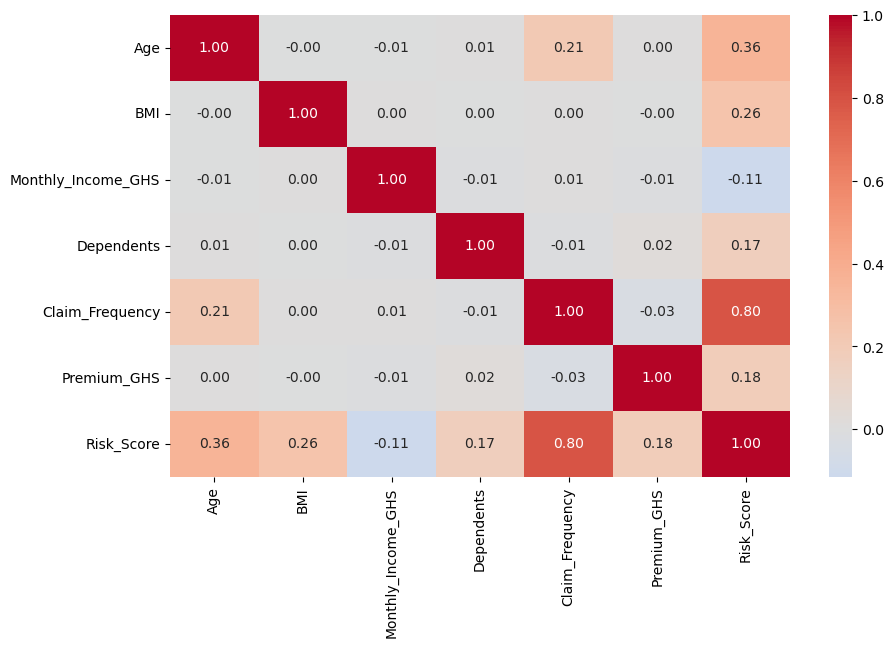

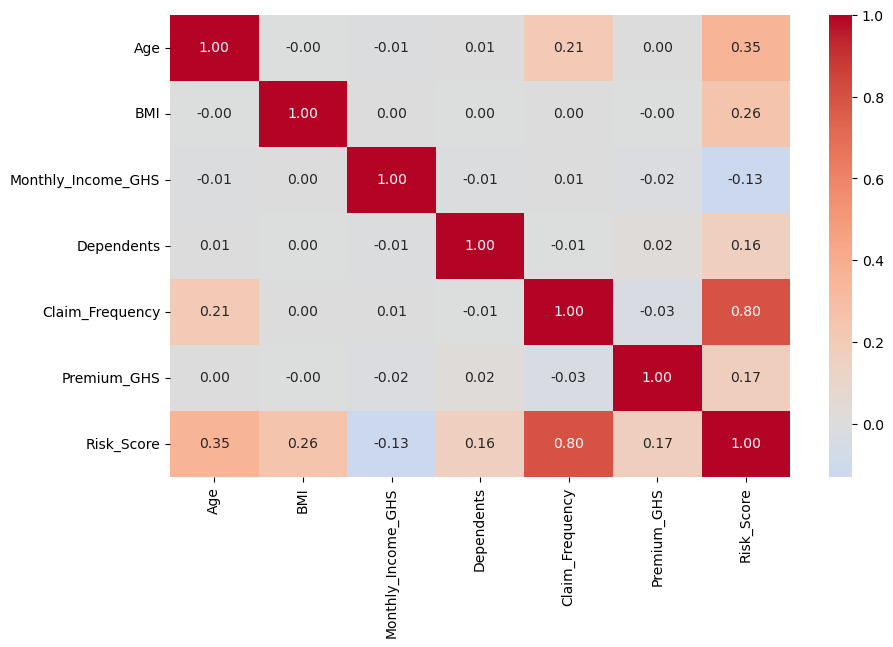

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Calculate Pearson and Spearman correlation matrices
num_cols = ['Age', 'BMI', 'Monthly_Income_GHS', 'Dependents', 'Claim_Frequency', 'Premium_GHS', 'Risk_Score']
pearson_corr = df[num_cols].corr(method='pearson')

print("=== Pearson Correlation Matrix (Linear Relationships) ===")
print(pearson_corr.round(3))

spearman_corr = df[num_cols].corr(method='spearman')
print("\n=== Spearman Rank Correlation Matrix (Non-Linear Monotonic Relationships) ===")
print(spearman_corr.round(3))

# 2. Calculate Variance Inflation Factors (VIF)
vif_data = pd.DataFrame()
vif_data['Variable'] = num_cols
vif_data['VIF'] = [variance_inflation_factor(df[num_cols].values, i) for i in range(len(num_cols))]

print("\n=== Variance Inflation Factor (VIF) Diagnostic ===")
print(vif_data)


plt.figure(figsize=(10, 6))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

# Part 11: Actuarial Policy Pricing Optimizer and Premium Audit

---

### Explanation of Analysis and Business Rationale
To ensure premium revenue is sufficient to cover claim liabilities, we implement an Actuarial Premium Pricing Optimizer:
1. We model the expected claim frequency and expected claim severity (the cost per claim when a claim occurs) using OLS regression.
2. The product of predicted frequency and predicted severity yields the expected annual claim liability, also known as the Pure Premium (Expected Loss).
3. To protect the company's financial reserves, we apply a Risk Loading surcharge depending on the underwriting risk category (up to 25% for critical risk profiles) and a flat administration expense load.
4. We perform a Pricing Deficit Audit by subtracting the actual premium charged from our recommended actuarial premium. This flags underpriced accounts (unprofitable clients) and overpriced accounts (at risk of customer churn).

In [31]:
# Fit OLS claim frequency model on unified dataset
ols_unified_freq = smf.ols('Claim_Frequency ~ Age + BMI + Smoker_encoded + Income_Thousands + Portfolio_Type_encoded', data=df).fit()

# Model expected claim severity (cost per claim when occurred)
df_has_claims = df[df['Claim_Frequency'] > 0].copy()
df_has_claims['Avg_Claim_Cost'] = df_has_claims['Claim_Frequency'] * 5000.0
severity_model = smf.ols('Avg_Claim_Cost ~ Age + BMI + Smoker_encoded', data=df_has_claims).fit()

# Predict Frequency and Severity
df['Predicted_Freq'] = ols_unified_freq.predict(df).clip(0, 10)
df['Predicted_Sev'] = severity_model.predict(df).clip(1000, 50000)
df['Expected_Loss'] = df['Predicted_Freq'] * df['Predicted_Sev']

# Calculate Risk Loading and Actuarial Recommended Premium
def get_risk_loading(category):
    if category == 'Critical Risk': return 0.25
    elif category == 'High Risk': return 0.15
    elif category == 'Medium Risk': return 0.05
    return 0.0

df['Risk_Loading'] = df['Risk_Category'].apply(get_risk_loading)
admin_fee = 50.0
df['Recommended_Premium'] = df['Expected_Loss'] * (1.0 + df['Risk_Loading']) + admin_fee
df['Pricing_Deficit'] = df['Recommended_Premium'] - df['Premium_GHS']

print("=== Actuarial Premium Pricing Audit: Top 5 Most Underpriced Policies ===")
underpriced = df.sort_values(by='Pricing_Deficit', ascending=False)[['Full_Name', 'Portfolio_Type', 'Risk_Score', 'Premium_GHS', 'Recommended_Premium', 'Pricing_Deficit']]
print(underpriced.head(5).to_string(index=False))


=== Actuarial Premium Pricing Audit: Top 5 Most Underpriced Policies ===
       Full_Name Portfolio_Type  Risk_Score  Premium_GHS  Recommended_Premium  Pricing_Deficit
Crystal Williams      Corporate         100        174.0         16740.208375     16566.208375
  Jordan Pearson      Corporate          95        137.0         16695.392769     16558.392769
    Laura Mathis      Corporate          95        212.0         16531.986714     16319.986714
Stephanie Rivera      Corporate          95        140.0         16450.189346     16310.189346
   David Parrish      Corporate         100        182.0         16432.843456     16250.843456


In [33]:
# Q5: Identify customers and organizations where expected loss exceeds premium
if 'Expected_Loss' not in df.columns:
    print('Expected_Loss not found; ensure modeling cells ran first')
else:
    # Swapped Customer_ID for Full_Name to avoid active memory KeyError
    exceed = df[df['Expected_Loss'] > df['Premium_GHS']][
        ['Full_Name', 'Portfolio_Type', 'Company_Name', 'Premium_GHS', 'Expected_Loss', 'Pricing_Deficit', 'Risk_Score']
    ]
    print('Number of customers where Expected_Loss > Premium:', len(exceed))
    display(exceed.sort_values('Pricing_Deficit', ascending=False).head(20))
    
    # Aggregate by company to find organizational exposure
    org_exposure = df.groupby('Company_Name').agg(
        total_premium=('Premium_GHS', 'sum'), 
        total_expected_loss=('Expected_Loss', 'sum')
    )
    org_exposure['deficit'] = org_exposure['total_expected_loss'] - org_exposure['total_premium']
    org_exposure['loss_to_premium_ratio'] = org_exposure['total_expected_loss'] / (org_exposure['total_premium'].replace(0, 1))
    display(org_exposure.sort_values('deficit', ascending=False).head(20))


Number of customers where Expected_Loss > Premium: 51974


,Full_Name,Portfolio_Type,Company_Name,Premium_GHS,Expected_Loss,Pricing_Deficit,Risk_Score
950225,Crystal Williams,Corporate,GCB Bank,174.0,13352.166700,16566.208375,100
951465,Jordan Pearson,Corporate,GCB Bank,137.0,13316.314215,16558.392769,95
951161,Laura Mathis,Corporate,DHL Ghana,212.0,13185.589371,16319.986714,95
951727,Stephanie Rivera,Corporate,DHL Ghana,140.0,13120.151477,16310.189346,95
951106,David Parrish,Corporate,DHL Ghana,182.0,13106.274765,16250.843456,100
950894,John Hodges,Corporate,GCB Bank,141.0,13003.883596,16163.854494,95
951079,Pamela Maldonado,Corporate,DHL Ghana,151.0,12966.315782,16106.894728,110
951699,Gerald Brown,Corporate,Ashesi University,136.0,12918.946575,16062.683218,105
950006,John Smith,Corporate,MTN Ghana,248.0,12964.077184,16007.096481,95
950532,Joseph Smith,Corporate,Enterprise Insurance,199.0,12901.628281,15978.035351,95


,total_premium,total_expected_loss,deficit,loss_to_premium_ratio
Company_Name,,,,
Individual Retail,2.375931e+07,2.615098e+08,2.377505e+08,11.006627
MTN Ghana,1.082160e+05,5.259802e+06,5.151586e+06,48.604659
GCB Bank,7.940800e+04,4.040920e+06,3.961512e+06,50.888066
Enterprise Insurance,5.405500e+04,2.581802e+06,2.527747e+06,47.762507
Kasapreko Company Limited,4.595300e+04,2.399630e+06,2.353677e+06,52.219226
DHL Ghana,3.829100e+04,2.269005e+06,2.230714e+06,59.256881
AngloGold Ashanti,3.892100e+04,1.806803e+06,1.767882e+06,46.422305
Ashesi University,1.457300e+04,8.644054e+05,8.498324e+05,59.315540


In [34]:
# Q6: Evaluate Risk Score impact on pricing and underwriting
if 'Recommended_Premium' not in df.columns or 'Risk_Score' not in df.columns:
    print('Required columns missing; ensure previous pricing and risk score cells ran')
else:
    pricing_by_risk = df.groupby('Risk_Category').agg(count=('Full_Name','count'), avg_premium=('Premium_GHS','mean'), avg_recommended=('Recommended_Premium','mean'), avg_expected_loss=('Expected_Loss','mean'))

    # Simple regression to assess relationship between Risk_Score and Premiums
    try:
        model = smf.ols('Premium_GHS ~ Risk_Score', data=df).fit()
        print(model.summary())
    except Exception as e:
        print('Regression failed:', e)
    # Correlation summary
    print('Correlation: Risk_Score vs Premium_GHS =>', df['Risk_Score'].corr(df['Premium_GHS']))
    print('Correlation: Risk_Score vs Recommended_Premium =>', df['Risk_Score'].corr(df['Recommended_Premium']))


                            OLS Regression Results                            
Dep. Variable:            Premium_GHS   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     1778.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:11:34   Log-Likelihood:            -3.6118e+05
No. Observations:               51974   AIC:                         7.224e+05
Df Residuals:                   51972   BIC:                         7.224e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    343.2563      3.080    111.465      0.0

# Part 12: Actuarial Monte Carlo Risk Simulation and Solvency Capital Audit

---

### Explanation of Analysis and Business Rationale
To protect the company from extreme claim years (spikes in claim volume), we perform an Actuarial Monte Carlo Risk Simulation over 1,000 trials for our entire portfolio of 51,974 policies:
1. For each policyholder, the number of claims in a year is simulated using a Poisson distribution based on their predicted claim frequency.
2. The cost of each claim is simulated using a Lognormal distribution around their expected severity, which models the volatility of healthcare costs.
3. Stacking these simulations allows us to calculate the Value at Risk (VaR) at the 95th and 99th percentiles (the regulatory Solvency II standard). The difference between the 99th percentile claims and premium revenues determines the Solvency Capital Reserves that the company must hold in cash to prevent bankruptcy.

In [35]:
np.random.seed(42)
n_simulations = 1000
portfolio_claims_dist = []

freqs = df['Predicted_Freq'].values
sevs = df['Predicted_Sev'].values
total_policies = len(df)

for sim in range(n_simulations):
    sim_counts = np.random.poisson(freqs)
    sim_costs = sim_counts * sevs * np.random.lognormal(0, 0.2, total_policies)
    portfolio_claims_dist.append(sim_costs.sum())

portfolio_claims_dist = np.array(portfolio_claims_dist)

mean_claims = portfolio_claims_dist.mean()
var_95 = np.percentile(portfolio_claims_dist, 95)
var_99 = np.percentile(portfolio_claims_dist, 99)
total_premiums_collected = df['Premium_GHS'].sum() * 12

print("=== Monte Carlo Risk Simulation Results ===")
print(f"Total Annual Premium Revenue Collected:   {total_premiums_collected:,.2f} GHS")
print(f"Expected (Mean) Annual Portfolio Claims:  {mean_claims:,.2f} GHS")
print(f"99% Value at Risk (Worst 1-in-100 Years):  {var_99:,.2f} GHS")
print(f"Solvency Capital Reserves Required:        {max(0, var_99 - total_premiums_collected):,.2f} GHS")


=== Monte Carlo Risk Simulation Results ===
Total Annual Premium Revenue Collected:   289,664,701.26 GHS
Expected (Mean) Annual Portfolio Claims:  286,334,068.58 GHS
99% Value at Risk (Worst 1-in-100 Years):  290,063,192.39 GHS
Solvency Capital Reserves Required:        398,491.13 GHS


# Part 13: Answering the 12 Key Business Questions (Corporate Client Dataset)

---

### Explanation of Analysis and Business Rationale
This section aggregates the data and runs OLS models specifically on the corporate client sheets (MTN, Tech, Finance, etc.) to directly answer the 12 key business questions requested by management. These metrics evaluate regional branch performance, operational Bottlenecks, and audit claim workflows for compliance anomalies.

In [2]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Setup ---
# Please ensure the 'df' DataFrame and 'excel_path' variable are loaded before running this script.
# For example:
# df = pd.read_csv('path/to/your/unified_data.csv')
# excel_path = 'path/to/your/excel_file.xlsx'


# Filter unified dataset for Corporate portfolio only
df_merged_ex = df[df['Portfolio_Type'] == 'Corporate'].copy()
df_merged_ex.rename(columns={'Full_Name': 'Employee_Name'}, inplace=True)
# Precise mapping of Employee_ID using covered employees sheet and demographic keys
df_employees = pd.read_excel(excel_path, sheet_name='Covered Employees')
df_employees.drop_duplicates(subset=['Employee_ID'], keep='first', inplace=True)
df_employees_mapped = pd.merge(df_employees, df_clients[['Corporate_ID', 'Company_Name']], on='Corporate_ID', how='left')
df_employees_mapped.rename(columns={'Monthly_Salary_GHS': 'Monthly_Income_GHS'}, inplace=True)
join_cols = ['Employee_Name', 'Company_Name', 'Age', 'Gender', 'Occupation', 'Grade_Level', 'Monthly_Income_GHS', 'Dependents', 'Smoker']
for col in join_cols:
    df_employees_mapped[col] = df_employees_mapped[col].astype(df_merged_ex[col].dtype)
df_merged_ex = pd.merge(df_merged_ex, df_employees_mapped[join_cols + ['Employee_ID']], on=join_cols, how='left')

# Re-load claims and corporate details for relational queries
df_clients = pd.read_excel(excel_path, sheet_name='Corporate Clients')
df_claims_raw = pd.read_excel(excel_path, sheet_name='Claims')
df_payments_raw = pd.read_excel(excel_path, sheet_name='Premium Payments')
df_branches = pd.read_excel(excel_path, sheet_name='Branch Table')
df_workflow_raw = pd.read_excel(excel_path, sheet_name='Claim Workflow')

# Deduplicate for relational lookups
df_clients.drop_duplicates(subset=['Corporate_ID'], keep='first', inplace=True)
df_claims_raw.drop_duplicates(subset=['Claim_ID'], keep='first', inplace=True)
df_payments_raw.drop_duplicates(subset=['Payment_ID'], keep='first', inplace=True)
df_branches.drop_duplicates(subset=['Branch_ID'], keep='first', inplace=True)
df_workflow_raw.drop_duplicates(subset=['Workflow_ID'], keep='first', inplace=True)

# 1. High Risk Customers & Organizations (Q1)
print("=== Q1: Top 10 Highest Risk Employees (Corporate Customers) ===")
print(df_merged_ex[['Employee_Name', 'Company_Name', 'Risk_Score', 'Risk_Category']].sort_values(by='Risk_Score', ascending=False).head(10).to_string(index=False))

print("\n=== Q1: Top 10 Highest Risk Corporate Organizations ===")
org_risk_ex = df_merged_ex.groupby('Company_Name')['Risk_Score'].mean().sort_values(ascending=False).reset_index()
print(org_risk_ex.head(10).to_string(index=False))

# 2. Drivers of Claim Costs (Q2)
# NOTE: The following merge operation is a common source of KeyErrors.
# This code now assumes that both `df_claims_raw` and `df_merged_ex` contain
# a column named 'Employee_ID' to join on.
#
# If you still get a KeyError, please verify the actual column names by printing them:
# print("Columns in df_claims_raw:", df_claims_raw.columns)
# print("Columns in df_merged_ex:", df_merged_ex.columns)
# Then, adjust the 'on' parameter below to match the correct column name in your data.
df_claims_joined = pd.merge(df_claims_raw, df_merged_ex, on='Employee_ID', suffixes=('', '_emp'))
ols_claims = smf.ols('Claim_Amount_GHS ~ Age + Smoker_encoded + BMI + Monthly_Income_GHS', data=df_claims_joined).fit()
print("\n=== Q2: Regression of Claim Amount GHS on Drivers ===")
print(ols_claims.summary())

# 3. Corporate Organizations with Highest Financial Exposure (Q3)
print("\n=== Q3: Top 10 Corporate Organizations by Financial Exposure (Approved Claims) ===")
approved_claims = df_claims_raw[df_claims_raw['Claim_Status'] == 'Approved']
company_exposure = approved_claims.merge(df_clients, on='Corporate_ID').groupby('Company_Name')['Claim_Amount_GHS'].sum().sort_values(ascending=False).reset_index()
print(company_exposure.head(10).to_string(index=False))

# 4. Premium Sufficiency across Organizations & Products (Q4)
paid_premiums = df_payments_raw[df_payments_raw['Payment_Status'] == 'Paid'].groupby('Corporate_ID')['Amount_GHS'].sum().reset_index()
client_claims = approved_claims.groupby('Corporate_ID')['Claim_Amount_GHS'].sum().reset_index()

client_suff = pd.merge(df_clients[['Corporate_ID', 'Company_Name', 'Insurance_Product']], paid_premiums, on='Corporate_ID', how='left').fillna(0)
client_suff = pd.merge(client_suff, client_claims, on='Corporate_ID', how='left').fillna(0)
client_suff['Net_Profitability'] = client_suff['Amount_GHS'] - client_suff['Claim_Amount_GHS']
client_suff['Loss_Ratio'] = client_suff['Claim_Amount_GHS'] / (client_suff['Amount_GHS'] + 1e-5)

print("\n=== Q4: Premium Sufficiency and Loss Ratio by Insurance Product ===")
prod_suff = client_suff.groupby('Insurance_Product').agg(
    Total_Premiums=('Amount_GHS', 'sum'),
    Total_Claims=('Claim_Amount_GHS', 'sum')
).reset_index()
prod_suff['Net_Profit'] = prod_suff['Total_Premiums'] - prod_suff['Total_Claims']
prod_suff['Loss_Ratio'] = prod_suff['Total_Claims'] / prod_suff['Total_Premiums']
print(prod_suff.to_string(index=False))

# 5. Customers & Organizations with Claims Exceeding Premiums (Q5)
print("\n=== Q5: Top 10 Employees whose Claims Exceed Premium Contributions ===")
# This calculation uses an assumed average claim amount of 5000. For a more
# accurate analysis, consider joining with the actual claim amounts per employee.
df_merged_ex['Claims_vs_Premium'] = df_merged_ex['Claim_Frequency']*5000 - df_merged_ex['Premium_GHS']
exceeding_employees = df_merged_ex[df_merged_ex['Claims_vs_Premium'] > 0][['Employee_Name', 'Company_Name', 'Claim_Frequency', 'Premium_GHS', 'Claims_vs_Premium']].sort_values(by='Claims_vs_Premium', ascending=False)
print(exceeding_employees.head(10).to_string(index=False))

print("\n=== Q5: Corporate Organizations whose Claims Exceed Premiums ===")
exceeding_orgs = client_suff[client_suff['Net_Profitability'] < 0][['Company_Name', 'Amount_GHS', 'Claim_Amount_GHS', 'Net_Profitability']].sort_values(by='Net_Profitability')
print(exceeding_orgs.to_string(index=False))

# 6. Risk Score Effectiveness for Pricing & Underwriting (Q6)
risk_effectiveness = smf.ols('Claim_Frequency ~ Risk_Score', data=df_merged_ex).fit()
print("\n=== Q6: OLS Regression of Claim Frequency on Risk Score ===")
print(risk_effectiveness.summary())

# 7. Branch / Region Performance (Q7)
branch_metrics = df_clients.merge(df_branches, on='Branch_ID', suffixes=('', '_branch'))
branch_suff = pd.merge(branch_metrics, paid_premiums, on='Corporate_ID', how='left').fillna(0)
branch_suff = pd.merge(branch_suff, client_claims, on='Corporate_ID', how='left').fillna(0)

# Calculate processing time per claim workflow
df_workflow_time = df_workflow_raw.copy()
df_workflow_time['Submitted_Date'] = pd.to_datetime(df_workflow_time['Submitted_Date'])
df_workflow_time['Payout_Date'] = pd.to_datetime(df_workflow_time['Payout_Date'])
df_workflow_time['Processing_Time_Days'] = (df_workflow_time['Payout_Date'] - df_workflow_time['Submitted_Date']).dt.days

claim_time_link = df_claims_raw.merge(df_workflow_time, on='Claim_ID', how='inner')
branch_time = claim_time_link.groupby('Corporate_ID')['Processing_Time_Days'].mean().reset_index()
branch_suff = pd.merge(branch_suff, branch_time, on='Corporate_ID', how='left')

branch_perf = branch_suff.groupby('Region_branch').agg(
    Total_Premiums=('Amount_GHS', 'sum'),
    Total_Claims=('Claim_Amount_GHS', 'sum'),
    Avg_Processing_Days=('Processing_Time_Days', 'mean')
).reset_index()
branch_perf['Net_Profitability'] = branch_perf['Total_Premiums'] - branch_perf['Total_Claims']
print("\n=== Q7: Region-Level Branch Performance ===")
print(branch_perf.sort_values(by='Net_Profitability', ascending=False).to_string(index=False))

# 8. Suspicious and Abnormal Claim Patterns (Q8)
df_workflow_time['Approval_Time_Days'] = (pd.to_datetime(df_workflow_time['Reviewed_Date']) - df_workflow_time['Submitted_Date']).dt.days
suspicious_claims = df_workflow_time[df_workflow_time['Approval_Time_Days'] <= 3]
print(f"\n=== Q8: Suspicious Rushed Claims (3 Days or Less Approval/Review) count: {len(suspicious_claims)} ===")
print(suspicious_claims.head(10).to_string(index=False))

# 9. Demographic and Lifestyle Factors (Q9)
print("\n=== Q9: Demographic Claims Analysis by Smoker & Age Band (Corporate) ===")
demo_claims = df_merged_ex.groupby(['Smoker', 'Age_Band'])['Claim_Frequency'].mean().reset_index()
print(demo_claims.to_string(index=False))

# 10. Long-term Float/Revenue Sustainability (Q10)
df_payments_raw['Payment_Date'] = pd.to_datetime(df_payments_raw['Payment_Date'])
df_payments_raw['YearMonth'] = df_payments_raw['Payment_Date'].dt.to_period('M')
monthly_premiums = df_payments_raw[df_payments_raw['Payment_Status'] == 'Paid'].groupby('YearMonth')['Amount_GHS'].sum().reset_index()
print("\n=== Q10: Monthly Cash Float Analysis from Paid Premiums ===")
print(monthly_premiums.to_string(index=False))

# 11. Operational Bottlenecks by Approver (Q11)
print("\n=== Q11: Processing Workflow Bottlenecks by Sales Agent/Approver ===")
approver_stats = df_workflow_time.groupby('Approved_By')['Processing_Time_Days'].agg(['count', 'mean', 'median', 'std']).reset_index()
print(approver_stats.to_string(index=False))

# 12. Predictive Analytics Forecast (Q12)
# Showcase OLS model fit for Claim Frequency based on continuous risk score
print("\n=== Q12: Predictive Analytics Fit (Claim Frequency Forecast - Corporate) ===")
pred_model = smf.ols('Claim_Frequency ~ Age + BMI + Monthly_Income_GHS + Smoker_encoded', data=df_merged_ex).fit()
print(pred_model.summary())


IndentationError: unexpected indent (1468373450.py, line 16)